# Behavior Analysis: LUPE-AMPS Analysis on Novel Data

Press SHIFT + ENTER to run code

### Section 1: USER INPUT

In [10]:
## Define project
project_name = ''

# Select group and condition, see meta.py to see how you previously defined it for your project
selected_groups = ['','']
selected_conditions = ['','']

In [12]:
## Define project
project_name = 'project_ACC_Study3_FormalinMorphine'

# Select group and condition, see meta.py to see how you previously defined it for your project
selected_groups = ['Male','Female']
selected_conditions = ['Group1_0mgkg','Group2_0.5mgkg','Group3_1.0mgkg','Group4_5mgkg','Group5_10mgkg']

In [13]:
# Recording parameters
sampling_rate = 60  # Original recording fps
target_fps = 20     # Downsampled fps for state model
recording_length = 30  # Recording length in minutes
bin_length = 5  # Bin length for statistics (minutes), set to 0 for no binning

# Minimum frames for a behavior to be considered "real" (100ms at 60fps = 6 frames)
min_frames_true_positive = 6

# Injury site for ALL animals
# 0 = left hindpaw (default in most LUPE studies - no flipping needed)
# 1 = right hindpaw (will swap labels 4 and 5 so "injured paw" is always label 4)
injury_site = 0

# Paths - MODIFY THESE FOR YOUR SETUP
base_data_dir = f'../processed_dataset/{project_name}/figures/behaviors_csv_raw-classification/frames'
output_base_dir = f'../processed_dataset/{project_name}/figures/behaviors_LUPE-AMPS'

# Model paths (pre-trained state centroids and PCA parameters)
# These files contain the validated state definitions and pain scale from the original publication
# Contact the Corder Lab if you don't have these files
model_path = '../model/panpainmodel30.mat'  # Or .pkl file with centroids
pca_model_path = '../model/pain_scale_params.mat'  # Or .pkl file with PCA params

# Behavior and state labels
behaviors = ['Still', 'Walking', 'Rearing', 'Grooming', 'LeftLick', 'RightLick']
states = ['State 1', 'State 2', 'State 3', 'State 4', 'State 5', 'State 6']

# State category mapping for display
state_categories = {
    1: "Pain Suppressed",
    2: "Non-pain State",
    3: "Pain Enhanced",
    4: "Pain Enhanced",
    5: "Non-pain State",
    6: "Non-pain State"
}

# %%
# Import required libraries
import os
import glob
import numpy as np
import pandas as pd
from scipy.stats import mode
from scipy.ndimage import label
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

warnings.filterwarnings('ignore')

# Derived parameters
n_behaviors = 6
original_length = recording_length * 60 * sampling_rate
downsampled_length = int(original_length * (target_fps / sampling_rate))
n_bins = recording_length // bin_length if bin_length > 0 else 1

# Window parameters for transition matrices
window_length_sec = 30
window_slide_sec = 10
window_size = target_fps * window_length_sec
window_slide = target_fps * window_slide_sec

print("Configuration loaded!")
print(f"Project: {project_name}")
print(f"Groups: {selected_groups}")
print(f"Conditions: {selected_conditions}")
print(f"Original frames: {original_length}, Downsampled: {downsampled_length}")

Configuration loaded!
Project: project_ACC_Study3_FormalinMorphine
Groups: ['Male', 'Female']
Conditions: ['Group1_0mgkg', 'Group2_0.5mgkg', 'Group3_1.0mgkg', 'Group4_5mgkg', 'Group5_10mgkg']
Original frames: 108000, Downsampled: 36000


In [14]:
### Section 2: DATA LOADING AND BEHAVIOR STATISTICS

In [15]:
def load_lupe_data(base_dir, groups, conditions, expected_length):
    behavior_data = []
    animal_names = []
    group_labels = []
    condition_labels = []
    
    for group in groups:
        group_dir = os.path.join(base_dir, group)
        if not os.path.exists(group_dir):
            print(f"Warning: Group directory not found: {group_dir}")
            continue
            
        for condition in conditions:
            condition_dir = os.path.join(group_dir, condition)
            if not os.path.exists(condition_dir):
                print(f"Warning: Condition directory not found: {condition_dir}")
                continue
            
            csv_files = sorted(glob.glob(os.path.join(condition_dir, "*.csv")))
            print(f"Found {len(csv_files)} files in {group}/{condition}")
            
            for file_path in csv_files:
                try:
                    data = pd.read_csv(file_path)
                    # Extract behavior column (2nd column)
                    behav_col = pd.to_numeric(data.iloc[:, 1], errors='coerce').fillna(0).to_numpy()
                    
                    # Ensure correct length
                    if len(behav_col) < expected_length:
                        behav = np.zeros(expected_length)
                        behav[:len(behav_col)] = behav_col
                    else:
                        behav = behav_col[:expected_length]
                    
                    behavior_data.append(behav.astype(int))
                    animal_names.append(os.path.basename(file_path)[:-4])
                    group_labels.append(group)
                    condition_labels.append(condition)
                    
                except Exception as e:
                    print(f"Error loading {file_path}: {e}")
                    continue
    
    if len(behavior_data) == 0:
        raise ValueError("No data files were successfully loaded!")
    
    behavior_matrix = np.column_stack(behavior_data)
    print(f"\nLoaded {behavior_matrix.shape[1]} animals, {behavior_matrix.shape[0]} frames each")
    
    return behavior_matrix, animal_names, group_labels, condition_labels


def find_bouts(binary_data, min_frames):
    bout_starts = []
    bout_ends = []
    
    diff = np.diff(binary_data)
    potential_starts = np.where(diff == 1)[0] + 1
    potential_ends = np.where(diff == -1)[0]
    
    for start in potential_starts:
        end_check = min(start + min_frames, len(binary_data))
        if np.all(binary_data[start:end_check] == 1):
            bout_starts.append(start)
    
    for end in potential_ends:
        start_check = max(end - min_frames + 1, 0)
        if np.all(binary_data[start_check:end + 1] == 1):
            bout_ends.append(end)
    
    return np.array(bout_starts), np.array(bout_ends)


def calculate_behavior_statistics(behavior_matrix, n_bins, bin_length, sampling_rate, n_behaviors, min_frames):
    n_animals = behavior_matrix.shape[1]
    bin_length_frames = bin_length * 60 * sampling_rate if bin_length > 0 else behavior_matrix.shape[0]
    
    total_fraction = np.zeros((n_animals, n_bins, n_behaviors))
    n_bouts = np.zeros((n_animals, n_bins, n_behaviors))
    bout_duration = np.zeros((n_animals, n_bins, n_behaviors))
    
    for k in range(n_animals):
        for b in range(n_behaviors):
            binary_data = (behavior_matrix[:, k] == b).astype(int)
            
            for n in range(n_bins):
                if bin_length == 0:
                    binned = binary_data
                else:
                    start_idx = n * bin_length_frames
                    end_idx = (n + 1) * bin_length_frames
                    binned = binary_data[start_idx:end_idx]
                
                if np.sum(binned) > 0:
                    bout_starts, bout_ends = find_bouts(binned, min_frames)
                    
                    if len(bout_starts) > 0 and len(bout_ends) > 0:
                        bout_ends = bout_ends[bout_ends >= bout_starts[0]]
                        if len(bout_ends) > 0:
                            bout_starts = bout_starts[bout_starts <= bout_ends[-1]]
                        
                        if len(bout_starts) > 0 and len(bout_ends) > 0:
                            n_valid = min(len(bout_starts), len(bout_ends))
                            durations = (bout_ends[:n_valid] - bout_starts[:n_valid]) / sampling_rate
                            
                            total_fraction[k, n, b] = np.mean(binned)
                            n_bouts[k, n, b] = len(bout_starts)
                            bout_duration[k, n, b] = np.mean(durations) if len(durations) > 0 else 0
    
    return total_fraction, n_bouts, bout_duration


# Load data
behavior_matrix, animal_names, group_labels, condition_labels = load_lupe_data(
    base_data_dir, selected_groups, selected_conditions, original_length
)

# Calculate behavior statistics
print("\nCalculating behavior statistics...")
total_fraction, n_bouts, bout_duration = calculate_behavior_statistics(
    behavior_matrix, n_bins, bin_length, sampling_rate, n_behaviors, min_frames_true_positive
)

# Aggregate across bins
total_frac_time = np.mean(total_fraction, axis=1)
total_num_bouts = np.sum(n_bouts, axis=1)
weighted_dur = bout_duration * n_bouts
total_mean_dur = np.sum(weighted_dur, axis=1) / (total_num_bouts + 1e-10)
total_mean_dur[np.isnan(total_mean_dur)] = 0
total_mean_dur[np.isinf(total_mean_dur)] = 0

print(f"Behavior statistics calculated for {total_frac_time.shape[0]} animals")

# Export behavior statistics
output_dir_section2 = os.path.join(output_base_dir, 'Section2_BehaviorStats')
os.makedirs(output_dir_section2, exist_ok=True)

for b, beh_name in enumerate(behaviors):
    df = pd.DataFrame({
        'FractionTime': total_frac_time[:, b],
        'NumBouts': total_num_bouts[:, b],
        'MeanDuration_s': total_mean_dur[:, b]
    }, index=animal_names)
    df['Group'] = group_labels
    df['Condition'] = condition_labels
    df.to_csv(os.path.join(output_dir_section2, f'{beh_name}_statistics.csv'))

print(f"Behavior statistics exported to: {output_dir_section2}")

Found 10 files in Male/Group1_0mgkg
Found 9 files in Male/Group2_0.5mgkg
Found 10 files in Male/Group3_1.0mgkg
Found 10 files in Male/Group4_5mgkg
Found 10 files in Male/Group5_10mgkg
Found 9 files in Female/Group1_0mgkg
Found 10 files in Female/Group2_0.5mgkg
Found 10 files in Female/Group3_1.0mgkg
Found 10 files in Female/Group4_5mgkg
Found 10 files in Female/Group5_10mgkg

Loaded 98 animals, 108000 frames each

Calculating behavior statistics...
Behavior statistics calculated for 98 animals
Behavior statistics exported to: ../processed_dataset/project_ACC_Study3_FormalinMorphine/figures/behaviors_LUPE-AMPS/Section2_BehaviorStats


### Section 3: BEHAVIOR VISUALIZATION

Conditions (sorted): ['Group1_0mgkg', 'Group2_0.5mgkg', 'Group3_1.0mgkg', 'Group4_5mgkg', 'Group5_10mgkg']


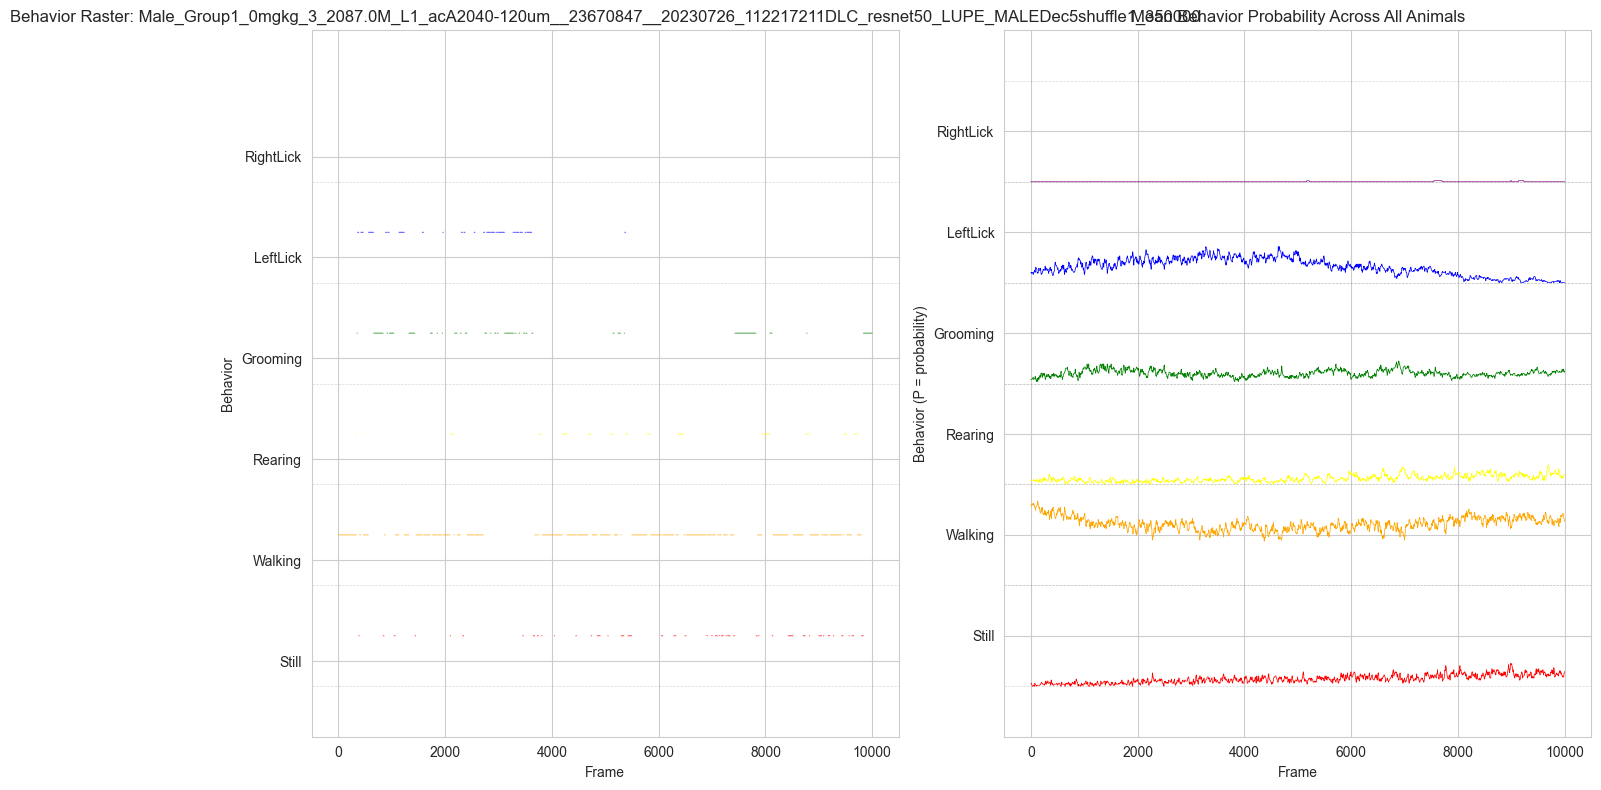

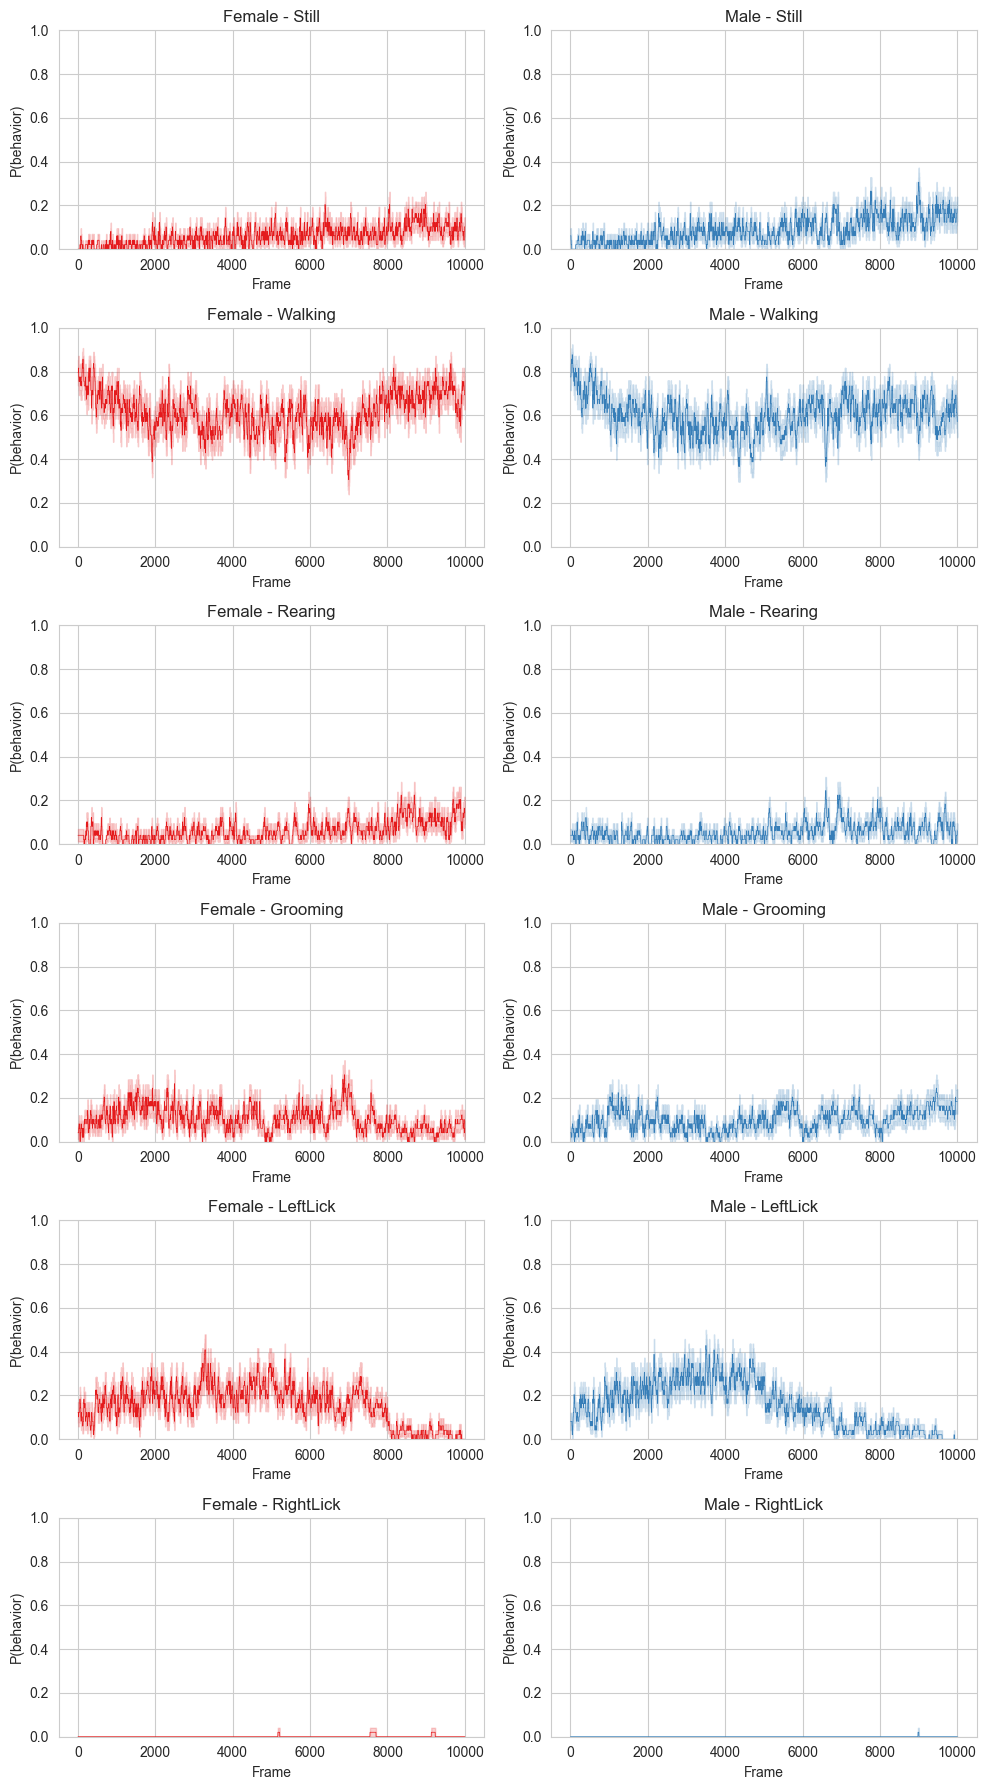

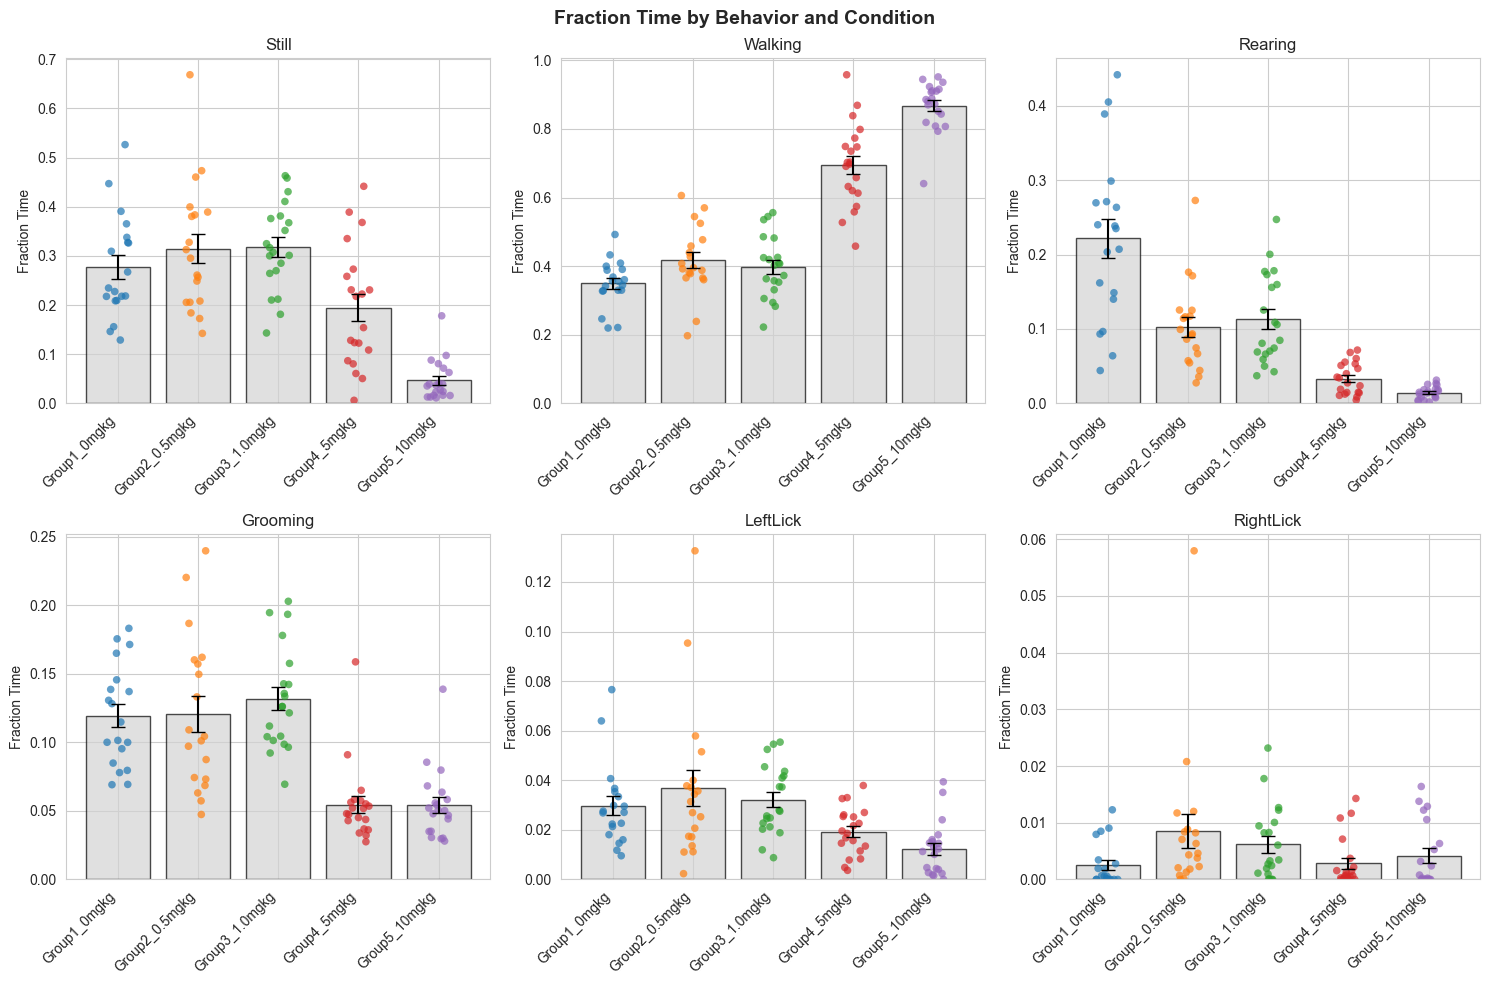

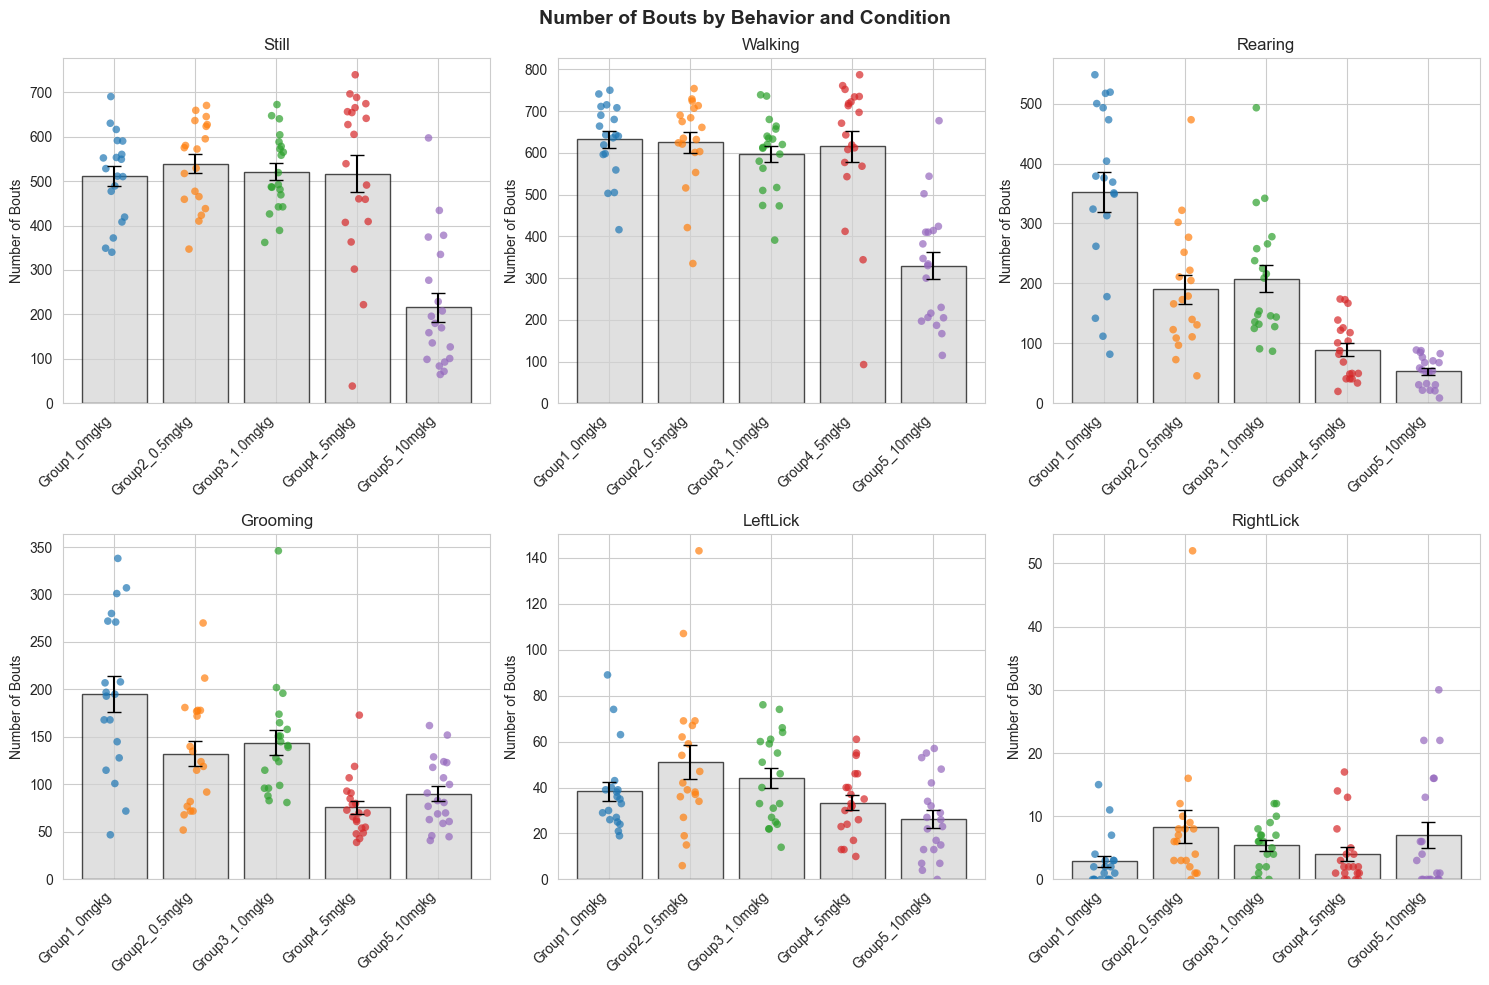

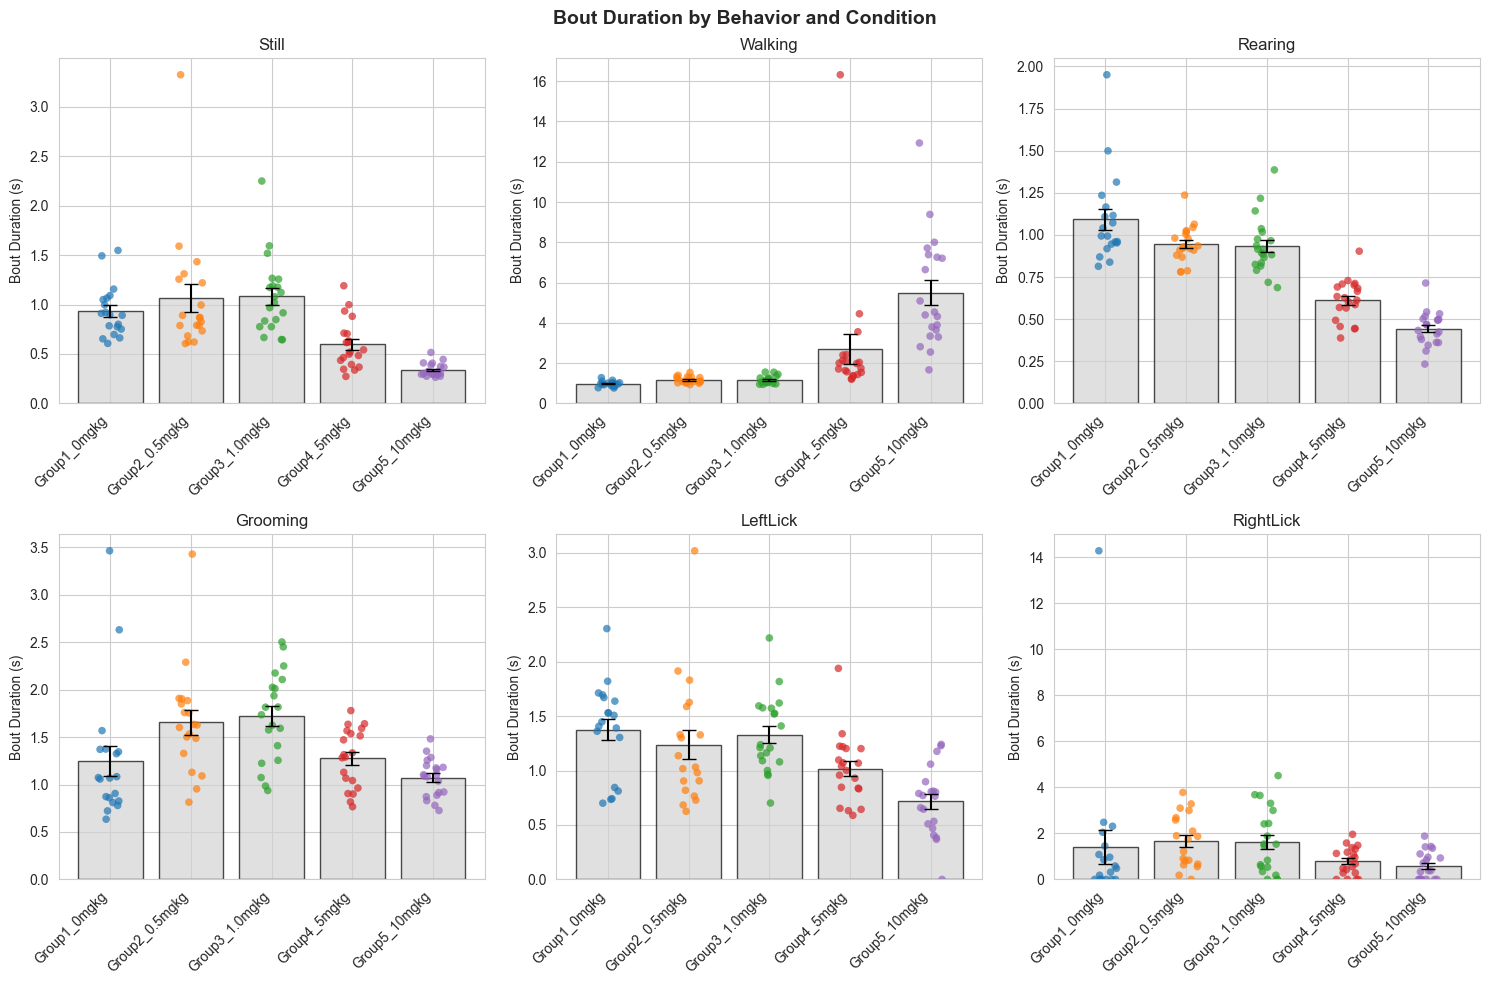

Behavior visualizations saved to: ../processed_dataset/project_ACC_Study3_FormalinMorphine/figures/behaviors_LUPE-AMPS/Section3_BehaviorViz


In [16]:
output_dir_section3 = os.path.join(output_base_dir, 'Section3_BehaviorViz')
os.makedirs(output_dir_section3, exist_ok=True)

behavior_colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple']

# Sort conditions alphabetically for consistent x-axis ordering
unique_conditions = sorted(list(set(condition_labels)))
palette = sns.color_palette('tab10', len(unique_conditions))
condition_colors = dict(zip(unique_conditions, palette))

print(f"Conditions (sorted): {unique_conditions}")

# 3a. Plot behavior raster for single animal and average across all animals
# Binary occurrence of each behavior over time, stacked vertically
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Single animal raster
animal_of_interest = 0
time_window = slice(0, min(10000, behavior_matrix.shape[0]))
frames = np.arange(time_window.start, time_window.stop)

ax = axes[0]
for b in range(n_behaviors):
    # Create binary trace: 1 when doing behavior b, 0 otherwise
    beh_trace = (behavior_matrix[time_window, animal_of_interest] == b).astype(float)
    # Scale to 0.5 height and offset by behavior index
    beh_trace_plot = beh_trace * 0.5 + b
    # Only plot where behavior occurs (set non-occurrences to NaN for gaps)
    beh_trace_plot[beh_trace == 0] = np.nan
    ax.plot(frames, beh_trace_plot, color=behavior_colors[b], linewidth=0.5, label=behaviors[b])
    ax.axhline(y=b, color='gray', linestyle='--', alpha=0.3, linewidth=0.5)

ax.set_ylim(-0.5, n_behaviors + 0.5)
ax.set_yticks(np.arange(n_behaviors) + 0.25)
ax.set_yticklabels(behaviors)
ax.set_xlabel('Frame')
ax.set_ylabel('Behavior')
ax.set_title(f'Behavior Raster: {animal_names[animal_of_interest]}')

# Average across all animals
ax = axes[1]
for b in range(n_behaviors):
    # Calculate probability of each behavior at each timepoint
    beh_prob = (behavior_matrix[time_window, :] == b).astype(float).mean(axis=1)
    # Offset by behavior index for stacked visualization
    ax.plot(frames, beh_prob + b, color=behavior_colors[b], linewidth=0.5, label=behaviors[b])
    ax.axhline(y=b, color='gray', linestyle='--', alpha=0.3, linewidth=0.5)
    ax.axhline(y=b + 1, color='gray', linestyle='--', alpha=0.3, linewidth=0.5)

ax.set_ylim(-0.5, n_behaviors + 0.5)
ax.set_yticks(np.arange(n_behaviors) + 0.5)
ax.set_yticklabels(behaviors)
ax.set_xlabel('Frame')
ax.set_ylabel('Behavior (P = probability)')
ax.set_title('Mean Behavior Probability Across All Animals')

plt.tight_layout()
plt.savefig(os.path.join(output_dir_section3, f'{project_name}_behavior_raster.png'), dpi=300)
plt.savefig(os.path.join(output_dir_section3, f'{project_name}_behavior_raster.svg'))
plt.show()

# 3b. Plot behavior probability over time by GROUP (like MATLAB Section 3b)
unique_groups = sorted(list(set(group_labels)))
time_window_prob = slice(0, min(10000, behavior_matrix.shape[0]))

fig, axes = plt.subplots(n_behaviors, len(unique_groups), figsize=(5 * len(unique_groups), 3 * n_behaviors))
if len(unique_groups) == 1:
    axes = axes.reshape(-1, 1)

group_colors = dict(zip(unique_groups, sns.color_palette('Set1', len(unique_groups))))

for b in range(n_behaviors):
    for g_idx, group in enumerate(unique_groups):
        ax = axes[b, g_idx]
        
        # Get animals in this group
        group_mask = np.array([gl == group for gl in group_labels])
        group_data = behavior_matrix[time_window_prob, :][:, group_mask]
        
        # Binary trace for behavior b
        beh_binary = (group_data == b).astype(float)
        
        # Mean and SEM across animals
        mean_beh = np.mean(beh_binary, axis=1)
        sem_beh = np.std(beh_binary, axis=1, ddof=1) / np.sqrt(beh_binary.shape[1])
        
        frames = np.arange(len(mean_beh))
        ax.plot(frames, mean_beh, color=group_colors[group], linewidth=0.5)
        ax.fill_between(frames, mean_beh - sem_beh, mean_beh + sem_beh, 
                        color=group_colors[group], alpha=0.2)
        
        ax.set_ylim(0, 1)
        ax.set_xlabel('Frame')
        ax.set_ylabel('P(behavior)')
        ax.set_title(f'{group} - {behaviors[b]}')

plt.tight_layout()
plt.savefig(os.path.join(output_dir_section3, f'{project_name}_behavior_probability_by_group.png'), dpi=300)
plt.savefig(os.path.join(output_dir_section3, f'{project_name}_behavior_probability_by_group.svg'))
plt.show()

# 3c. Plot behavior statistics by condition (bar plots with individual points)
# Fraction Time, Number of Bouts, Bout Duration - with SORTED x-axis

# Create figure for Fraction Time
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for b, beh_name in enumerate(behaviors):
    ax = axes[b]
    
    # Calculate means and SEMs for each condition (in sorted order)
    means = []
    sems = []
    
    for cond in unique_conditions:  # Already sorted alphabetically
        mask = np.array([c == cond for c in condition_labels])
        data = total_frac_time[mask, b]
        means.append(np.mean(data))
        sems.append(np.std(data, ddof=1) / np.sqrt(len(data)) if len(data) > 1 else 0)
    
    x = np.arange(len(unique_conditions))
    ax.bar(x, means, yerr=sems, capsize=5, color='lightgray', edgecolor='black', alpha=0.7)
    
    # Overlay individual points
    for i, cond in enumerate(unique_conditions):
        mask = np.array([c == cond for c in condition_labels])
        data = total_frac_time[mask, b]
        # Add jitter for visibility
        jitter = np.random.uniform(-0.15, 0.15, size=len(data))
        ax.scatter(np.ones(len(data)) * i + jitter, data, 
                   c=[condition_colors[cond]], s=30, alpha=0.7, edgecolors='none')
    
    ax.set_xticks(x)
    ax.set_xticklabels(unique_conditions, rotation=45, ha='right')
    ax.set_ylabel('Fraction Time')
    ax.set_title(beh_name)

plt.suptitle('Fraction Time by Behavior and Condition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir_section3, f'{project_name}_behavior_fraction_by_condition.png'), dpi=300)
plt.savefig(os.path.join(output_dir_section3, f'{project_name}_behavior_fraction_by_condition.svg'))
plt.show()

# Create figure for Number of Bouts
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for b, beh_name in enumerate(behaviors):
    ax = axes[b]
    
    means = []
    sems = []
    
    for cond in unique_conditions:
        mask = np.array([c == cond for c in condition_labels])
        data = total_num_bouts[mask, b]
        means.append(np.mean(data))
        sems.append(np.std(data, ddof=1) / np.sqrt(len(data)) if len(data) > 1 else 0)
    
    x = np.arange(len(unique_conditions))
    ax.bar(x, means, yerr=sems, capsize=5, color='lightgray', edgecolor='black', alpha=0.7)
    
    for i, cond in enumerate(unique_conditions):
        mask = np.array([c == cond for c in condition_labels])
        data = total_num_bouts[mask, b]
        jitter = np.random.uniform(-0.15, 0.15, size=len(data))
        ax.scatter(np.ones(len(data)) * i + jitter, data,
                   c=[condition_colors[cond]], s=30, alpha=0.7, edgecolors='none')
    
    ax.set_xticks(x)
    ax.set_xticklabels(unique_conditions, rotation=45, ha='right')
    ax.set_ylabel('Number of Bouts')
    ax.set_title(beh_name)

plt.suptitle('Number of Bouts by Behavior and Condition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir_section3, f'{project_name}_behavior_bouts_by_condition.png'), dpi=300)
plt.savefig(os.path.join(output_dir_section3, f'{project_name}_behavior_bouts_by_condition.svg'))
plt.show()

# Create figure for Bout Duration
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for b, beh_name in enumerate(behaviors):
    ax = axes[b]
    
    means = []
    sems = []
    
    for cond in unique_conditions:
        mask = np.array([c == cond for c in condition_labels])
        data = total_mean_dur[mask, b]
        means.append(np.mean(data))
        sems.append(np.std(data, ddof=1) / np.sqrt(len(data)) if len(data) > 1 else 0)
    
    x = np.arange(len(unique_conditions))
    ax.bar(x, means, yerr=sems, capsize=5, color='lightgray', edgecolor='black', alpha=0.7)
    
    for i, cond in enumerate(unique_conditions):
        mask = np.array([c == cond for c in condition_labels])
        data = total_mean_dur[mask, b]
        jitter = np.random.uniform(-0.15, 0.15, size=len(data))
        ax.scatter(np.ones(len(data)) * i + jitter, data,
                   c=[condition_colors[cond]], s=30, alpha=0.7, edgecolors='none')
    
    ax.set_xticks(x)
    ax.set_xticklabels(unique_conditions, rotation=45, ha='right')
    ax.set_ylabel('Bout Duration (s)')
    ax.set_title(beh_name)

plt.suptitle('Bout Duration by Behavior and Condition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir_section3, f'{project_name}_behavior_duration_by_condition.png'), dpi=300)
plt.savefig(os.path.join(output_dir_section3, f'{project_name}_behavior_duration_by_condition.svg'))
plt.show()

print(f"Behavior visualizations saved to: {output_dir_section3}")

### Section 4: PREPROCESSING - DOWNSAMPLING

In [17]:
def flip_injury_site(behavior_matrix, injury_site):
    """Flip left/right lick labels if injury was on right paw."""
    if injury_site == 0:
        return behavior_matrix  # No change needed - left paw is default
    
    # Right paw injury - swap labels 4 and 5
    flipped = behavior_matrix.copy()
    mask_4 = flipped == 4
    mask_5 = flipped == 5
    flipped[mask_4] = 5
    flipped[mask_5] = 4
    
    return flipped


def downsample_behavior(behavior_matrix, sampling_rate, target_fps):
    """Downsample behavior from original fps to target fps using mode."""
    rate_ratio = target_fps / sampling_rate
    n_downsampled = int(behavior_matrix.shape[0] * rate_ratio)
    n_animals = behavior_matrix.shape[1]
    
    downsampled = np.zeros((n_downsampled, n_animals), dtype=int)
    
    for n in range(n_downsampled - 1):
        start_idx = int(n / rate_ratio)
        end_idx = int((n + 1) / rate_ratio)
        
        for a in range(n_animals):
            window = behavior_matrix[start_idx:end_idx, a]
            if len(window) > 0:
                mode_result = mode(window, keepdims=False)
                downsampled[n, a] = int(np.floor(mode_result.mode))
    
    return downsampled


# Flip injury sites if needed (right paw injury -> swap labels 4 and 5)
# Downsample from original fps to target fps
try:
    behavior_matrix_flipped = flip_injury_site(behavior_matrix, injury_site)
    behavior_ds = downsample_behavior(behavior_matrix_flipped, sampling_rate, target_fps)
    
    print("=" * 60)
    print("SECTION 4: PREPROCESSING COMPLETE ✅")
    print("=" * 60)
    print(f"  Injury site: {'LEFT' if injury_site == 0 else 'RIGHT'} hindpaw")
    print(f"  Downsampled: {sampling_rate} fps → {target_fps} fps")
    print(f"  Original shape: {behavior_matrix.shape}")
    print(f"  Downsampled shape: {behavior_ds.shape}")
    print("=" * 60)

except Exception as e:
    print("=" * 60)
    print("SECTION 4: PREPROCESSING FAILED ❌")
    print("=" * 60)
    print(f"  Error: {e}")
    print("=" * 60)
    raise

SECTION 4: PREPROCESSING COMPLETE ✅
  Injury site: LEFT hindpaw
  Downsampled: 60 fps → 20 fps
  Original shape: (108000, 98)
  Downsampled shape: (36000, 98)


### Section 5: GENERATE TRANSITION MATRICES

In [18]:
def generate_transition_matrices(behavior_ds, n_behaviors, window_size, window_slide):
    """Generate unfolded transition matrices for each animal."""
    n_animals = behavior_ds.shape[1]
    total_frames = behavior_ds.shape[0]
    
    # Calculate window boundaries
    wins = np.arange(0, total_frames, window_slide)
    wins = wins[wins + window_size < total_frames]
    n_wins = len(wins)
    
    print(f"Generating {n_wins} transition matrices per animal...")
    
    trans_unfolded = np.zeros((n_wins, n_behaviors**2, n_animals))
    
    for a in range(n_animals):
        # Add 1 to convert from 0-indexed to 1-indexed (MATLAB convention)
        data = behavior_ds[:, a] + 1
        
        for t in range(n_wins):
            start_idx = wins[t]
            end_idx = start_idx + window_size
            window = data[start_idx:end_idx]
            
            # Calculate transition matrix
            T = np.zeros((n_behaviors, n_behaviors))
            
            for n in range(1, n_behaviors + 1):
                for l in range(1, n_behaviors + 1):
                    idx = np.where(window == n)[0]
                    idx = idx[idx < len(window) - 1]
                    
                    if len(idx) > 0:
                        T[n-1, l-1] = np.mean(window[idx + 1] == l)
            
            trans_unfolded[t, :, a] = T.flatten()
    
    # Replace NaNs with zeros
    trans_unfolded = np.nan_to_num(trans_unfolded, nan=0.0)
    
    return trans_unfolded, wins, n_wins


# Generate transition matrices
trans_unfolded, wins, n_wins = generate_transition_matrices(
    behavior_ds, n_behaviors, window_size, window_slide
)
print(f"Transition matrices shape: {trans_unfolded.shape}")
print(f"  - {n_wins} time windows")
print(f"  - {n_behaviors**2} features (unfolded {n_behaviors}x{n_behaviors} matrix)")
print(f"  - {trans_unfolded.shape[2]} animals")

Generating 177 transition matrices per animal...
Transition matrices shape: (177, 36, 98)
  - 177 time windows
  - 36 features (unfolded 6x6 matrix)
  - 98 animals


### Section 6: APPLY STATE MODEL

Loading state centroids from: ../model/panpainmodel30.mat
Centroids shape: (6, 36)
State assignments shape: (177, 98)
Frame-level states shape: (36000, 98)
Calculating shuffled model fits (100 iterations)...

Calculating behavior transitions per state...
Calculating state-to-state transitions...

Generating behavior transition matrices per state...


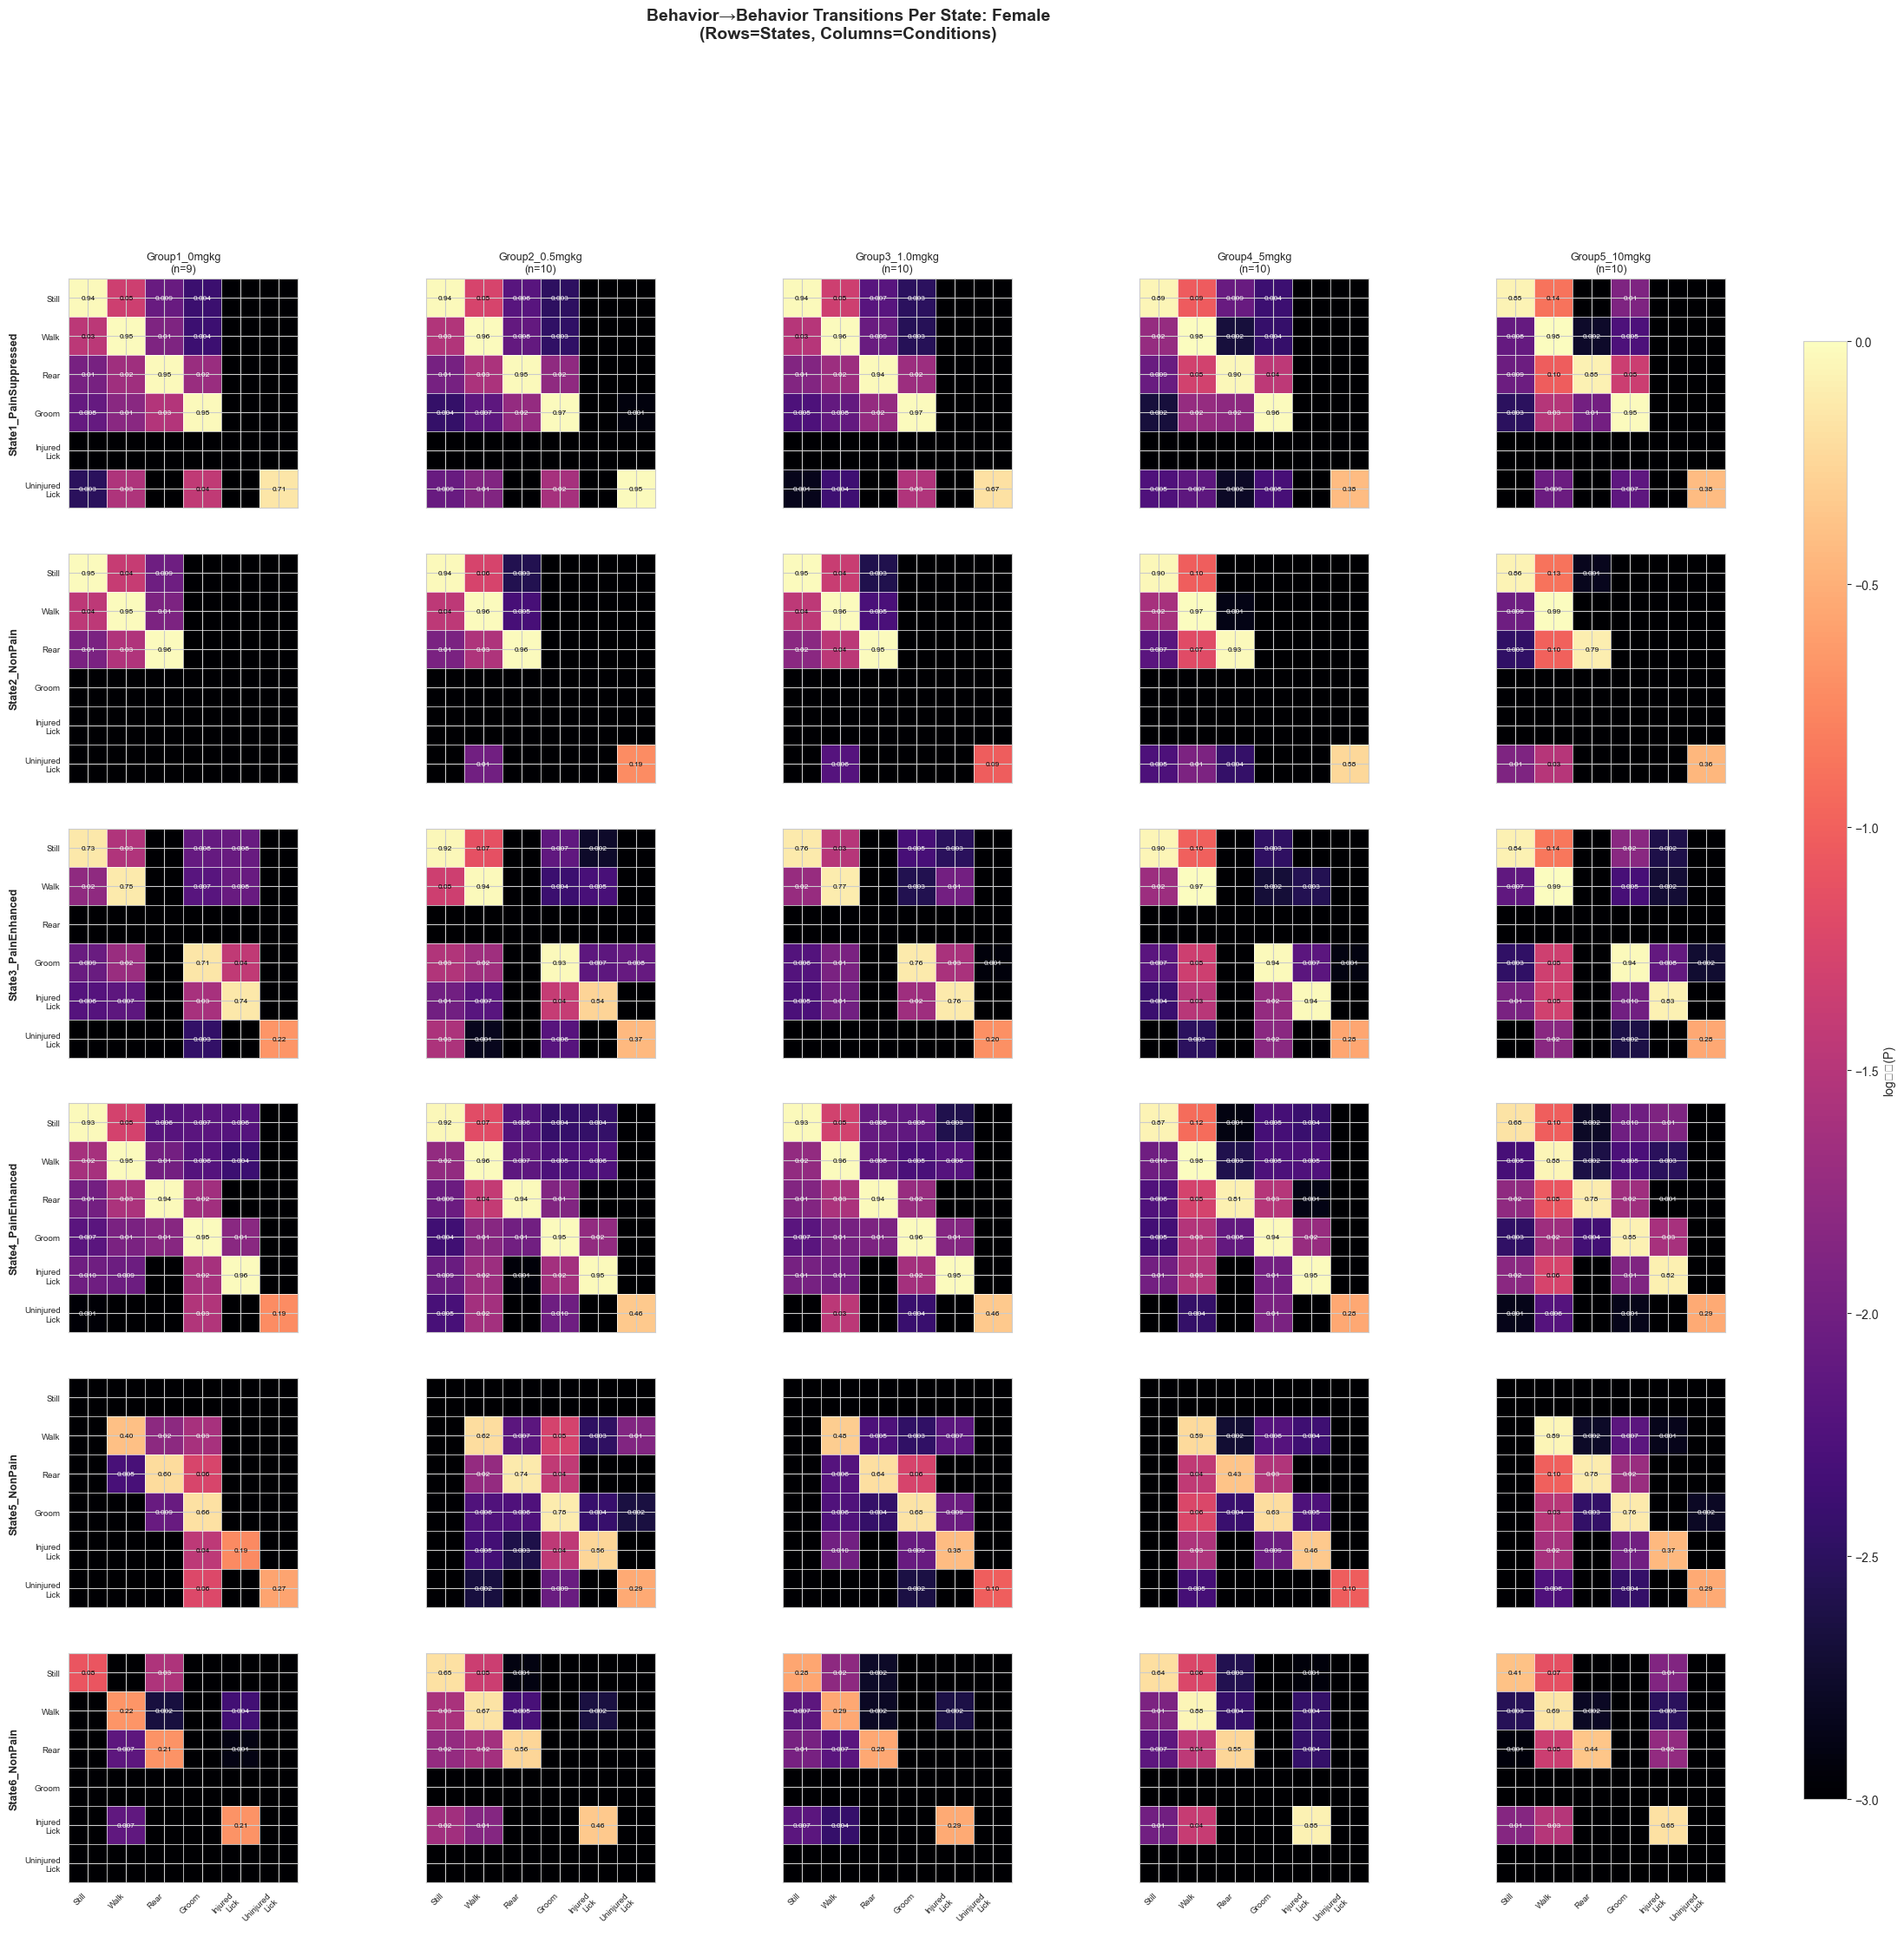

  - Saved behavior transitions for Female


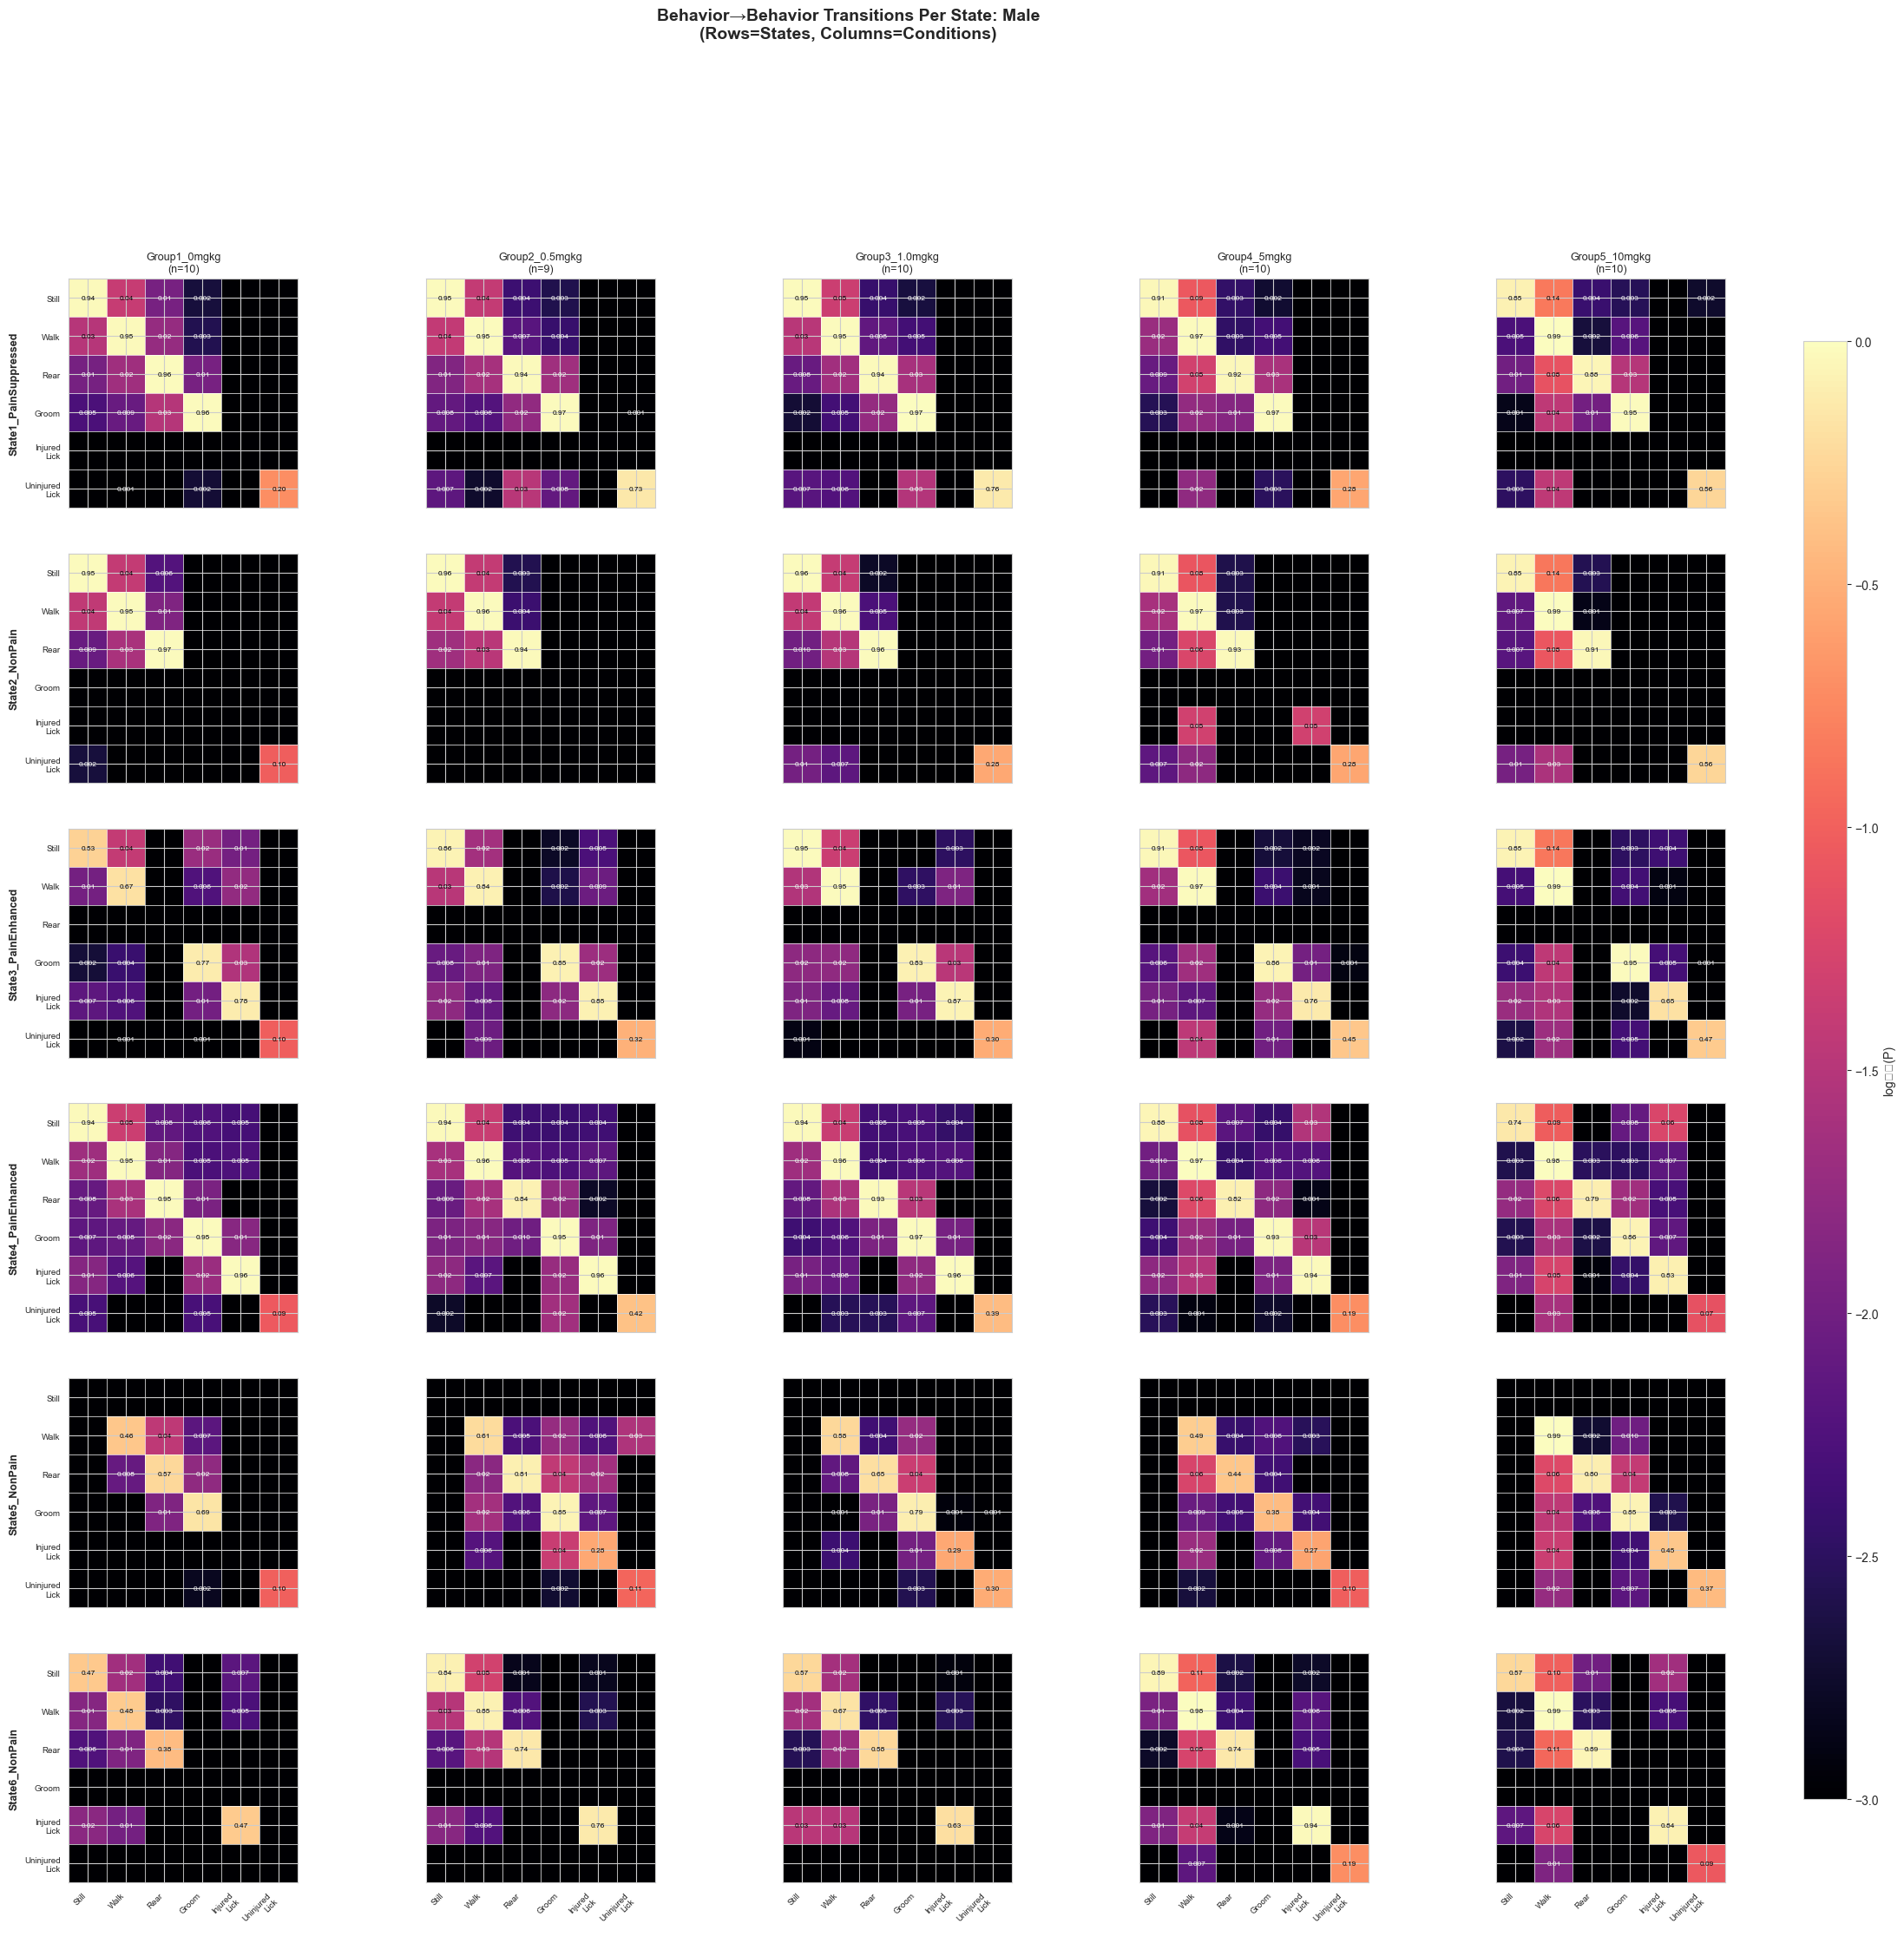

  - Saved behavior transitions for Male

Behavior transitions per state saved to: ../processed_dataset/project_ACC_Study3_FormalinMorphine/figures/behaviors_LUPE-AMPS/Section6_StateModel/behavior_transitions_per_state/

Generating state-to-state transition matrices...


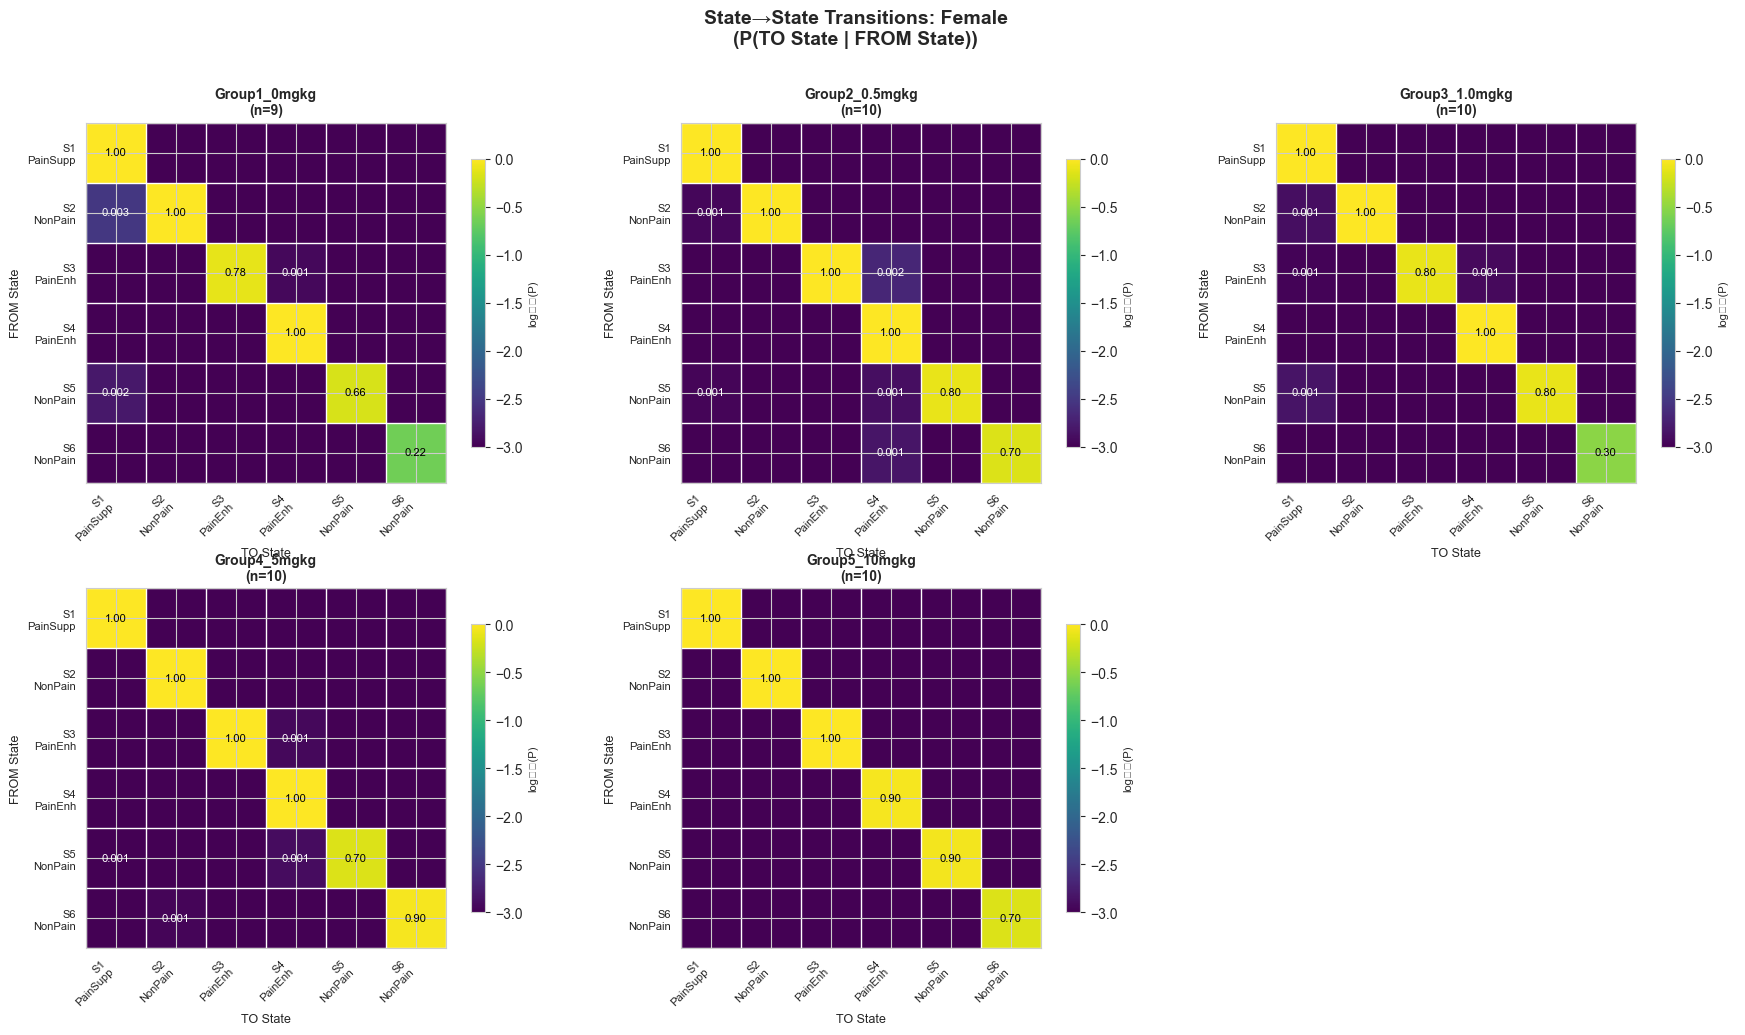

  - Saved state transitions for Female


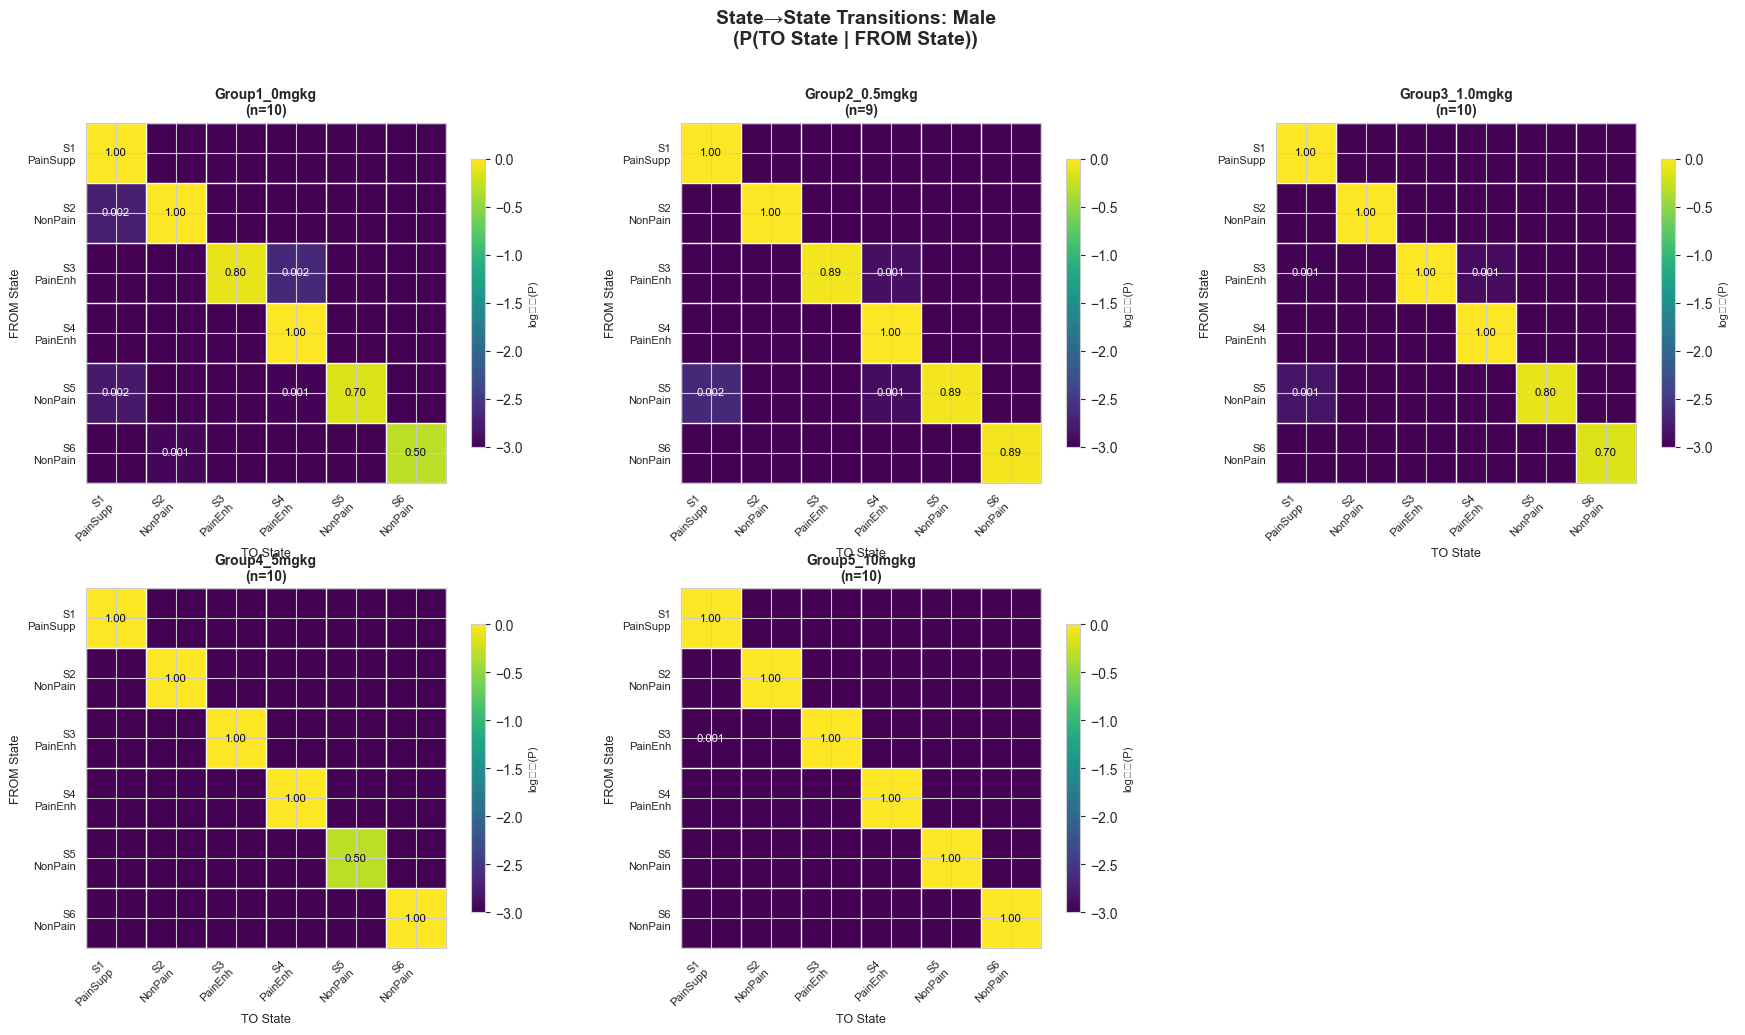

  - Saved state transitions for Male

State-to-state transitions saved to: ../processed_dataset/project_ACC_Study3_FormalinMorphine/figures/behaviors_LUPE-AMPS/Section6_StateModel/state_to_state_transitions/

Generating model fit validation...


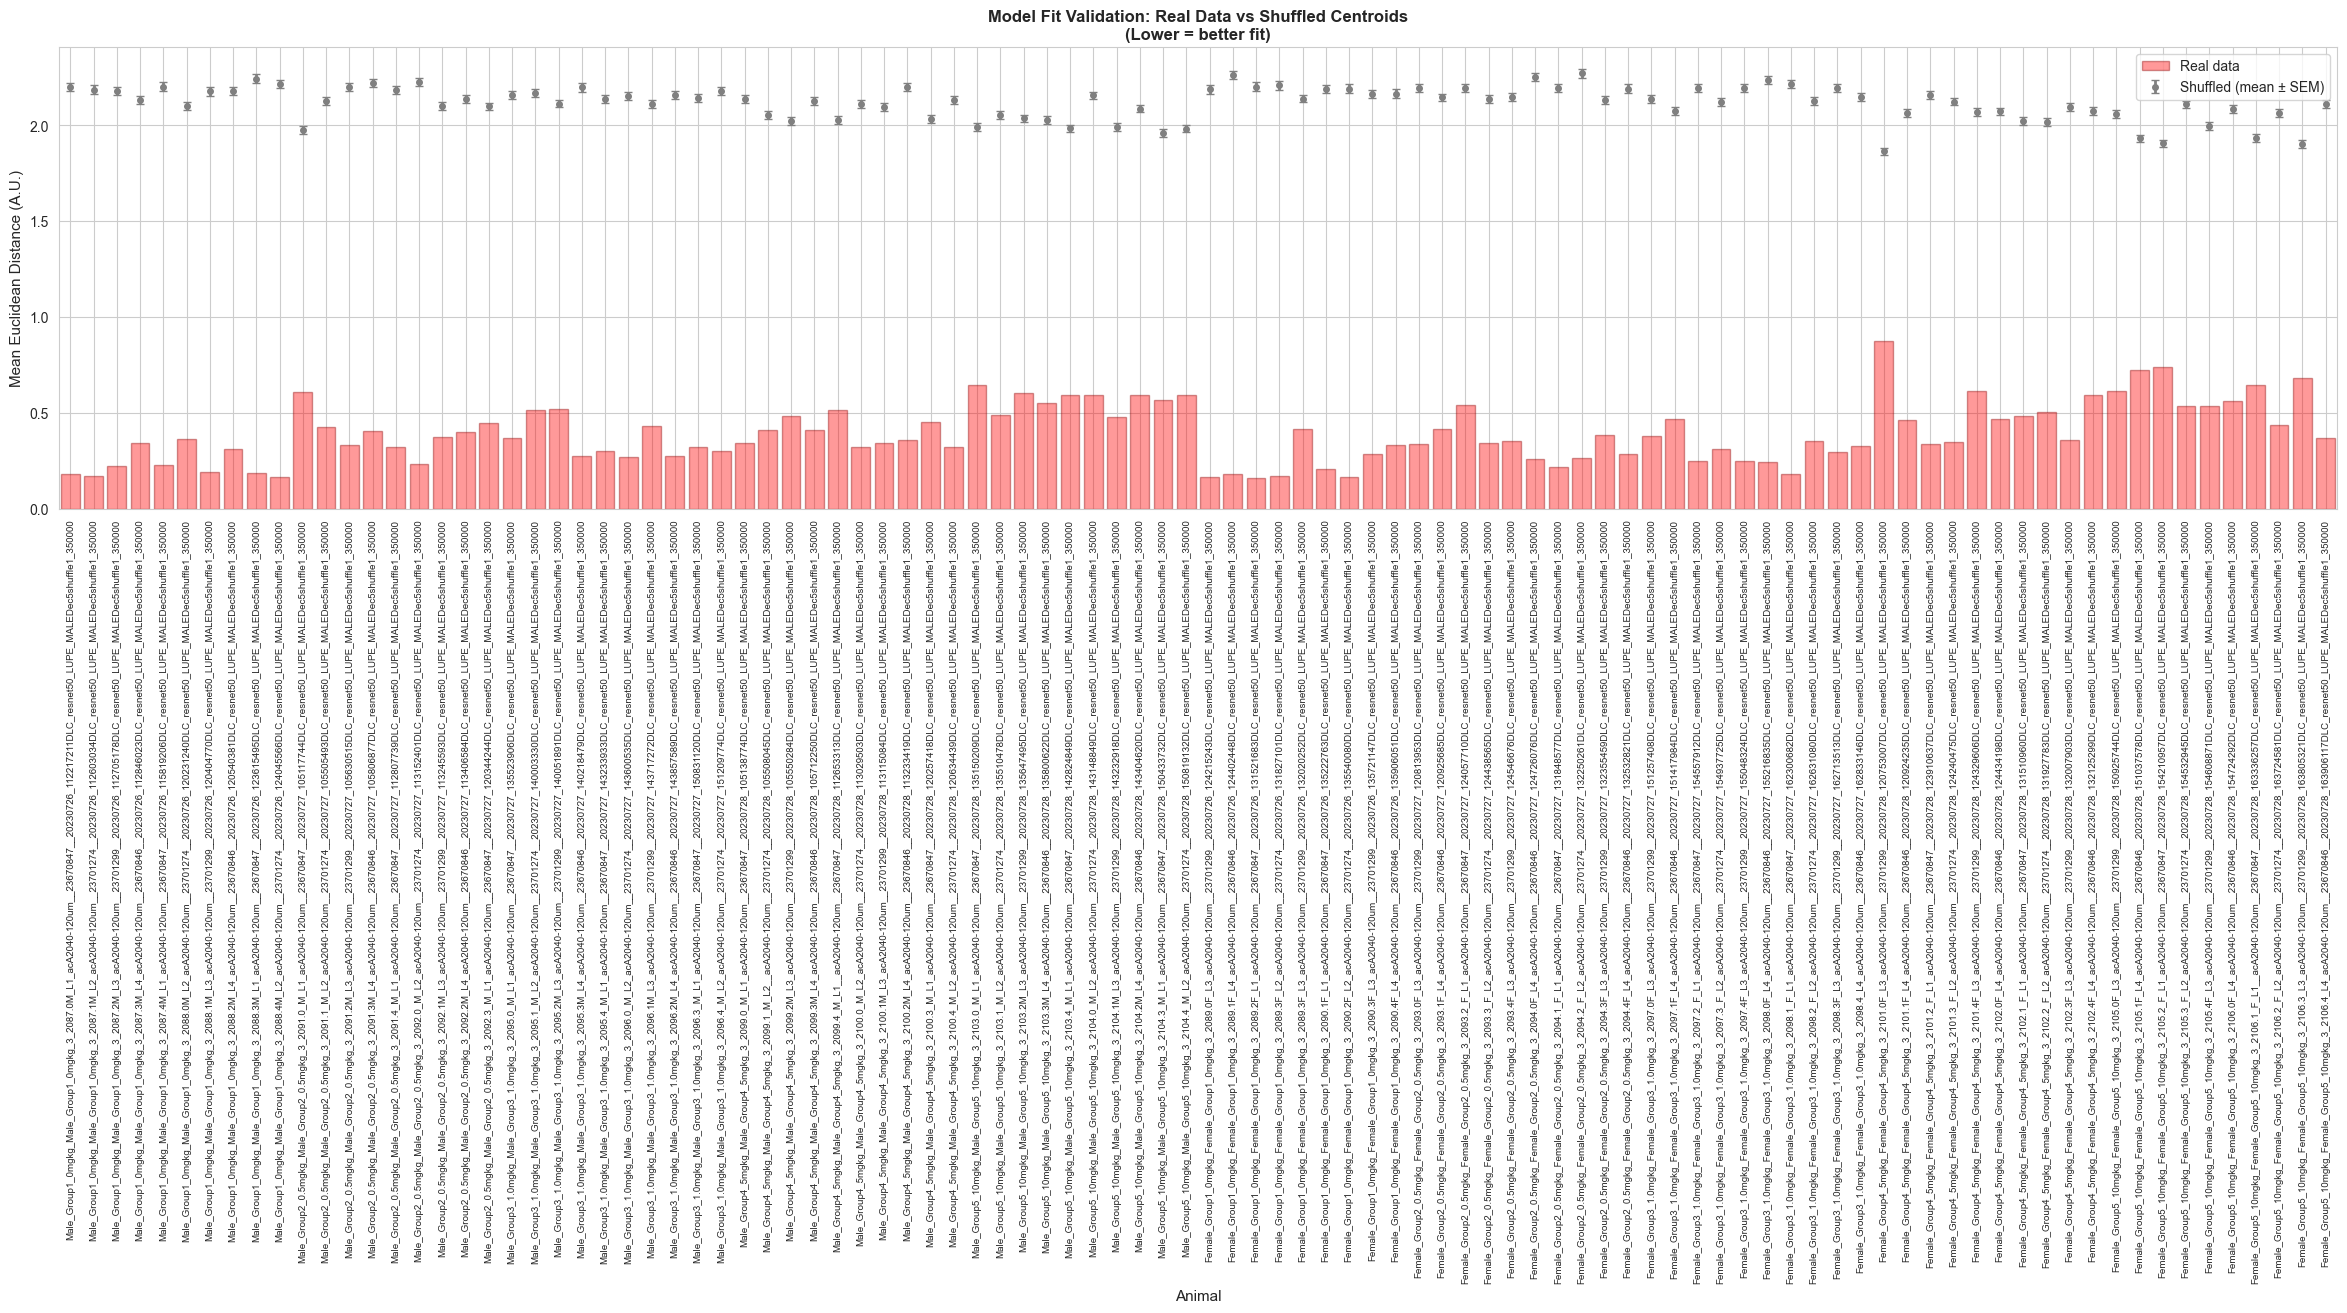

Model fit validation saved to: ../processed_dataset/project_ACC_Study3_FormalinMorphine/figures/behaviors_LUPE-AMPS/Section6_StateModel/model_fit_validation/

Exporting individual state fractions...
Individual state fractions saved to: ../processed_dataset/project_ACC_Study3_FormalinMorphine/figures/behaviors_LUPE-AMPS/Section6_StateModel/individual_state_fractions/

SECTION 6: STATE MODEL COMPLETE ✅
  States assigned for 98 animals
  Groups: ['Female', 'Male']
  Conditions: ['Group1_0mgkg', 'Group2_0.5mgkg', 'Group3_1.0mgkg', 'Group4_5mgkg', 'Group5_10mgkg']
  Real model fit (mean ± SEM): 0.3949 ± 0.0154
  Shuffled model fit (mean): 2.1181

Output directory: ../processed_dataset/project_ACC_Study3_FormalinMorphine/figures/behaviors_LUPE-AMPS/Section6_StateModel/

  behavior_transitions_per_state/
    - project_ACC_Study3_FormalinMorphine_behavior_transitions_per_state_{group}.png/svg
    - project_ACC_Study3_FormalinMorphine_behavior_trans_{group}_{condition}_State{1-6}.csv
    - proj

In [26]:
### Section 6: APPLY STATE MODEL
# =============================================================================
# SECTION 6: APPLY STATE MODEL
# =============================================================================

def load_state_centroids(model_path):
    """Load pre-trained state centroids from file."""
    if model_path.endswith('.pkl'):
        with open(model_path, 'rb') as f:
            data = pickle.load(f)
            if isinstance(data, dict):
                for key in ['centroids', 'c', 'centers']:
                    if key in data:
                        return np.array(data[key])
            return np.array(data)
    elif model_path.endswith('.npy'):
        return np.load(model_path)
    elif model_path.endswith('.mat'):
        from scipy.io import loadmat
        data = loadmat(model_path)
        for key in ['c', 'centroids', 'centers']:
            if key in data:
                return np.array(data[key]).squeeze()
        raise KeyError(f"Could not find centroids in .mat file. Keys: {list(data.keys())}")
    else:
        raise ValueError(f"Unsupported file format: {model_path}")


def assign_states(trans_unfolded, centroids):
    """Assign states based on minimum distance to centroids."""
    n_wins, n_features, n_animals = trans_unfolded.shape

    state_assignments = np.zeros((n_wins, n_animals), dtype=int)
    min_distances = np.zeros((n_wins, n_animals))

    for a in range(n_animals):
        data = trans_unfolded[:, :, a]
        distances = cdist(data, centroids, metric='euclidean')
        state_assignments[:, a] = np.argmin(distances, axis=1) + 1  # 1-indexed
        min_distances[:, a] = np.min(distances, axis=1)

    return state_assignments, min_distances


def resample_states(state_assignments, window_slide, window_size, target_length):
    """Resample state assignments from window-level to frame-level."""
    n_wins, n_animals = state_assignments.shape
    behav_state = np.zeros((target_length, n_animals), dtype=int)

    for a in range(n_animals):
        for t in range(n_wins):
            start_idx = window_slide * t
            end_idx = min(start_idx + window_size, target_length)
            behav_state[start_idx:end_idx, a] = state_assignments[t, a]

    return behav_state


def calculate_model_fit(trans_unfolded, centroids, n_shuffles=100):
    """Calculate model fit compared to shuffled centroids."""
    n_wins, n_features, n_animals = trans_unfolded.shape

    # Real model fit
    _, real_distances = assign_states(trans_unfolded, centroids)
    real_fit = np.mean(real_distances, axis=0)

    # Shuffled fits
    print(f"Calculating shuffled model fits ({n_shuffles} iterations)...")
    shuffled_fit = np.zeros((n_animals, n_shuffles))

    for v in range(n_shuffles):
        perm = np.random.permutation(n_features)
        shuffled_centroids = centroids[:, perm]

        for a in range(n_animals):
            data = trans_unfolded[:, :, a]
            distances = cdist(data, shuffled_centroids, metric='euclidean')
            shuffled_fit[a, v] = np.mean(np.min(distances, axis=1))

    return real_fit, shuffled_fit


def calculate_behavior_transitions_per_state(behavior_ds, behav_state, n_behaviors, n_states):
    """
    Calculate behavior→behavior transition matrices WITHIN each state.
    Returns: dict[state] = (n_animals, n_behaviors, n_behaviors) array of transition probabilities
    """
    n_frames, n_animals = behavior_ds.shape

    # Initialize: for each state, store transition counts per animal
    state_transitions = {}
    for s in range(1, n_states + 1):
        state_transitions[s] = np.zeros((n_animals, n_behaviors, n_behaviors))

    for a in range(n_animals):
        for t in range(n_frames - 1):
            current_state = behav_state[t, a]
            current_behavior = behavior_ds[t, a]
            next_behavior = behavior_ds[t + 1, a]

            if current_state >= 1 and current_state <= n_states:
                if current_behavior < n_behaviors and next_behavior < n_behaviors:
                    state_transitions[current_state][a, current_behavior, next_behavior] += 1

    # Convert counts to probabilities
    for s in range(1, n_states + 1):
        for a in range(n_animals):
            for b in range(n_behaviors):
                row_sum = np.sum(state_transitions[s][a, b, :])
                if row_sum > 0:
                    state_transitions[s][a, b, :] /= row_sum

    return state_transitions


def calculate_state_transitions(behav_state, n_states):
    """
    Calculate state→state transition matrices.
    Returns: (n_animals, n_states, n_states) array of transition probabilities
    """
    n_frames, n_animals = behav_state.shape

    # Initialize transition counts
    state_trans = np.zeros((n_animals, n_states, n_states))

    for a in range(n_animals):
        for t in range(n_frames - 1):
            current_state = behav_state[t, a]
            next_state = behav_state[t + 1, a]

            if current_state >= 1 and current_state <= n_states and next_state >= 1 and next_state <= n_states:
                state_trans[a, current_state - 1, next_state - 1] += 1

    # Convert counts to probabilities
    for a in range(n_animals):
        for s in range(n_states):
            row_sum = np.sum(state_trans[a, s, :])
            if row_sum > 0:
                state_trans[a, s, :] /= row_sum

    return state_trans


# -----------------------------------------------------------------------------
# LOAD MODEL AND ASSIGN STATES
# -----------------------------------------------------------------------------
print(f"Loading state centroids from: {model_path}")
try:
    centroids = load_state_centroids(model_path)
    print(f"Centroids shape: {centroids.shape}")
except Exception as e:
    print(f"Error loading centroids: {e}")
    raise ValueError("Cannot proceed without valid state centroids. Please check model_path.")

# Assign states to each animal
state_assignments, min_distances = assign_states(trans_unfolded, centroids)
print(f"State assignments shape: {state_assignments.shape}")

# Resample to frame-level
behav_state = resample_states(state_assignments, window_slide, window_size, behavior_ds.shape[0])
print(f"Frame-level states shape: {behav_state.shape}")

# Calculate model fit
real_fit, shuffled_fit = calculate_model_fit(trans_unfolded, centroids, n_shuffles=100)
shuffled_mean = np.mean(shuffled_fit, axis=1)
shuffled_sem = np.std(shuffled_fit, axis=1, ddof=1) / np.sqrt(shuffled_fit.shape[1])

# -----------------------------------------------------------------------------
# CREATE OUTPUT DIRECTORY STRUCTURE
# -----------------------------------------------------------------------------
output_dir_section6 = os.path.join(output_base_dir, 'Section6_StateModel')
output_dir_behavior_trans = os.path.join(output_dir_section6, 'behavior_transitions_per_state')
output_dir_state_trans = os.path.join(output_dir_section6, 'state_to_state_transitions')
output_dir_modelfit = os.path.join(output_dir_section6, 'model_fit_validation')
output_dir_statefractions = os.path.join(output_dir_section6, 'individual_state_fractions')

os.makedirs(output_dir_behavior_trans, exist_ok=True)
os.makedirs(output_dir_state_trans, exist_ok=True)
os.makedirs(output_dir_modelfit, exist_ok=True)
os.makedirs(output_dir_statefractions, exist_ok=True)

# State column names (descriptive)
state_column_names = {
    1: 'State1_PainSuppressed',
    2: 'State2_NonPain',
    3: 'State3_PainEnhanced',
    4: 'State4_PainEnhanced',
    5: 'State5_NonPain',
    6: 'State6_NonPain'
}

# State descriptions (short form for plot labels)
state_short_names = {
    1: 'S1\nPainSupp',
    2: 'S2\nNonPain',
    3: 'S3\nPainEnh',
    4: 'S4\nPainEnh',
    5: 'S5\nNonPain',
    6: 'S6\nNonPain'
}

# Behavior labels
behaviors_redefined = ['Still', 'Walk', 'Rear', 'Groom', 'Injured\nLick', 'Uninjured\nLick']
behaviors_csv = ['Still', 'Walk', 'Rear', 'Groom', 'Injured_Lick', 'Uninjured_Lick']

# Get unique groups and conditions (sorted)
unique_groups = sorted(list(set(group_labels)))
unique_conditions = sorted(list(set(condition_labels)))

n_states = 6

# -----------------------------------------------------------------------------
# CALCULATE TRANSITIONS
# -----------------------------------------------------------------------------
print("\nCalculating behavior transitions per state...")
behavior_trans_per_state = calculate_behavior_transitions_per_state(
    behavior_ds, behav_state, n_behaviors, n_states
)

print("Calculating state-to-state transitions...")
state_trans = calculate_state_transitions(behav_state, n_states)

# -----------------------------------------------------------------------------
# FIGURE 1: BEHAVIOR→BEHAVIOR TRANSITIONS PER STATE (Option B)
# One figure per group, with states as rows and conditions as columns
# -----------------------------------------------------------------------------
print("\nGenerating behavior transition matrices per state...")

all_behavior_trans_data = []

for group in unique_groups:
    # Create figure: rows = 6 states, columns = conditions
    n_conds = len(unique_conditions)

    fig, axes = plt.subplots(n_states, n_conds, figsize=(5 * n_conds, 4 * n_states))
    if n_conds == 1:
        axes = axes.reshape(-1, 1)

    for state_idx in range(n_states):
        state = state_idx + 1

        for cond_idx, cond in enumerate(unique_conditions):
            ax = axes[state_idx, cond_idx]

            # Get animals in this group AND condition
            mask = np.array([(g == group and c == cond) for g, c in zip(group_labels, condition_labels)])
            n_animals_subset = np.sum(mask)

            if n_animals_subset == 0:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=10)
                ax.set_title(f'{cond}', fontsize=9)
                ax.axis('off')
                continue

            # Get transition matrices for this state, group, condition
            animal_indices = np.where(mask)[0]
            trans_matrices = behavior_trans_per_state[state][animal_indices, :, :]

            # Mean across animals
            mean_trans = np.mean(trans_matrices, axis=0)

            # Log transform for visualization
            trans_log = np.log10(mean_trans + 1e-10)

            # Plot heatmap
            im = ax.imshow(trans_log, cmap='magma', aspect='equal', vmin=-3, vmax=0)

            # Add cell values
            for i in range(n_behaviors):
                for j in range(n_behaviors):
                    value = mean_trans[i, j]
                    text_color = 'white' if trans_log[i, j] < -1.5 else 'black'
                    if value >= 0.01:
                        text = f'{value:.2f}'
                    elif value >= 0.001:
                        text = f'{value:.3f}'
                    else:
                        text = ''  # Don't show very small values
                    ax.text(j, i, text, ha='center', va='center', fontsize=6, color=text_color)

            # Gridlines
            ax.set_xticks(np.arange(-0.5, n_behaviors, 1), minor=True)
            ax.set_yticks(np.arange(-0.5, n_behaviors, 1), minor=True)
            ax.grid(which='minor', color='white', linestyle='-', linewidth=0.5)

            # Labels
            ax.set_xticks(range(n_behaviors))
            ax.set_yticks(range(n_behaviors))

            if state_idx == n_states - 1:  # Bottom row
                ax.set_xticklabels(behaviors_redefined, rotation=45, ha='right', fontsize=7)
            else:
                ax.set_xticklabels([])

            if cond_idx == 0:  # First column
                ax.set_yticklabels(behaviors_redefined, fontsize=7)
                ax.set_ylabel(f'{state_column_names[state]}', fontsize=9, fontweight='bold')
            else:
                ax.set_yticklabels([])

            if state_idx == 0:  # Top row
                ax.set_title(f'{cond}\n(n={n_animals_subset})', fontsize=9)

            # Store for CSV export
            for i in range(n_behaviors):
                for j in range(n_behaviors):
                    all_behavior_trans_data.append({
                        'Group': group,
                        'Condition': cond,
                        'State': state_column_names[state],
                        'FROM_Behavior': behaviors_csv[i],
                        'TO_Behavior': behaviors_csv[j],
                        'Transition_Probability': mean_trans[i, j],
                        'N_Animals': int(n_animals_subset)
                    })

            # Export individual CSV for this group × condition × state
            df_matrix = pd.DataFrame(mean_trans, index=behaviors_csv, columns=behaviors_csv)
            df_matrix.index.name = 'FROM_Behavior'
            filename_clean = f'{project_name}_behavior_trans_{group}_{cond}_State{state}'.replace('/', '_').replace(' ',
                                                                                                                    '_')
            df_matrix.to_csv(os.path.join(output_dir_behavior_trans, f'{filename_clean}.csv'))

    # Add colorbar
    fig.subplots_adjust(right=0.92)
    cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap='magma', norm=plt.Normalize(vmin=-3, vmax=0))
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('log₁₀(P)', fontsize=10)

    plt.suptitle(f'Behavior→Behavior Transitions Per State: {group}\n(Rows=States, Columns=Conditions)',
                 fontsize=14, fontweight='bold', y=1.01)

    fig_filename = f'{project_name}_behavior_transitions_per_state_{group}'
    plt.savefig(os.path.join(output_dir_behavior_trans, f'{fig_filename}.png'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(output_dir_behavior_trans, f'{fig_filename}.svg'), bbox_inches='tight')
    plt.show()

    print(f"  - Saved behavior transitions for {group}")

# Export all behavior transition data to CSV
df_all_behavior_trans = pd.DataFrame(all_behavior_trans_data)
df_all_behavior_trans.to_csv(
    os.path.join(output_dir_behavior_trans, f'{project_name}_behavior_transitions_per_state_all.csv'), index=False)

print(f"\nBehavior transitions per state saved to: {output_dir_behavior_trans}/")

# -----------------------------------------------------------------------------
# FIGURE 2: STATE→STATE TRANSITIONS (Option C)
# One heatmap per group × condition showing how animals transition between states
# -----------------------------------------------------------------------------
print("\nGenerating state-to-state transition matrices...")

all_state_trans_data = []

# State labels for axes
state_labels = [f'S{i}' for i in range(1, 7)]
state_labels_full = [state_column_names[i] for i in range(1, 7)]

for group in unique_groups:
    n_conds = len(unique_conditions)
    n_cols = min(3, n_conds)
    n_rows = int(np.ceil(n_conds / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    if n_conds == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)

    for idx, cond in enumerate(unique_conditions):
        row = idx // n_cols
        col = idx % n_cols
        ax = axes[row, col]

        # Get animals in this group AND condition
        mask = np.array([(g == group and c == cond) for g, c in zip(group_labels, condition_labels)])
        n_animals_subset = np.sum(mask)

        if n_animals_subset == 0:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=12)
            ax.set_title(f'{cond}\n(n=0)', fontsize=10, fontweight='bold')
            ax.axis('off')
            continue

        # Get state transition matrices for this group × condition
        animal_indices = np.where(mask)[0]
        trans_matrices = state_trans[animal_indices, :, :]

        # Mean across animals
        mean_trans = np.mean(trans_matrices, axis=0)

        # Log transform for visualization (state transitions tend to have higher values)
        trans_log = np.log10(mean_trans + 1e-10)

        # Plot heatmap
        im = ax.imshow(trans_log, cmap='viridis', aspect='equal', vmin=-3, vmax=0)

        # Add cell values
        for i in range(n_states):
            for j in range(n_states):
                value = mean_trans[i, j]
                text_color = 'white' if trans_log[i, j] < -1.5 else 'black'
                if value >= 0.01:
                    text = f'{value:.2f}'
                elif value >= 0.001:
                    text = f'{value:.3f}'
                else:
                    text = ''
                ax.text(j, i, text, ha='center', va='center', fontsize=8, color=text_color)

        # Gridlines
        ax.set_xticks(np.arange(-0.5, n_states, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, n_states, 1), minor=True)
        ax.grid(which='minor', color='white', linestyle='-', linewidth=1)

        # Labels
        ax.set_xticks(range(n_states))
        ax.set_yticks(range(n_states))
        ax.set_xticklabels([state_short_names[i] for i in range(1, 7)], rotation=45, ha='right', fontsize=8)
        ax.set_yticklabels([state_short_names[i] for i in range(1, 7)], fontsize=8)
        ax.set_xlabel('TO State', fontsize=9)
        ax.set_ylabel('FROM State', fontsize=9)
        ax.set_title(f'{cond}\n(n={n_animals_subset})', fontsize=10, fontweight='bold')

        # Colorbar
        cbar = plt.colorbar(im, ax=ax, shrink=0.8)
        cbar.set_label('log₁₀(P)', fontsize=8)

        # Store for CSV export
        for i in range(n_states):
            for j in range(n_states):
                all_state_trans_data.append({
                    'Group': group,
                    'Condition': cond,
                    'FROM_State': state_column_names[i + 1],
                    'TO_State': state_column_names[j + 1],
                    'Transition_Probability': mean_trans[i, j],
                    'N_Animals': int(n_animals_subset)
                })

        # Export individual CSV for this group × condition
        df_matrix = pd.DataFrame(mean_trans, index=state_labels_full, columns=state_labels_full)
        df_matrix.index.name = 'FROM_State'
        filename_clean = f'{project_name}_state_trans_{group}_{cond}'.replace('/', '_').replace(' ', '_')
        df_matrix.to_csv(os.path.join(output_dir_state_trans, f'{filename_clean}.csv'))

    # Hide empty subplots
    for idx in range(n_conds, n_rows * n_cols):
        row = idx // n_cols
        col = idx % n_cols
        axes[row, col].axis('off')

    plt.suptitle(f'State→State Transitions: {group}\n(P(TO State | FROM State))',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()

    fig_filename = f'{project_name}_state_transitions_{group}'
    plt.savefig(os.path.join(output_dir_state_trans, f'{fig_filename}.png'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(output_dir_state_trans, f'{fig_filename}.svg'), bbox_inches='tight')
    plt.show()

    print(f"  - Saved state transitions for {group}")

# Export all state transition data to CSV
df_all_state_trans = pd.DataFrame(all_state_trans_data)
df_all_state_trans.to_csv(os.path.join(output_dir_state_trans, f'{project_name}_state_transitions_all.csv'),
                          index=False)

print(f"\nState-to-state transitions saved to: {output_dir_state_trans}/")

# -----------------------------------------------------------------------------
# FIGURE 3: Model Fit Validation (Real vs Shuffled)
# -----------------------------------------------------------------------------
print("\nGenerating model fit validation...")

animal_labels = [f'{g}_{c}_{a}' for g, c, a in zip(group_labels, condition_labels, animal_names)]

fig, ax = plt.subplots(figsize=(max(12, len(animal_labels) * 0.3), 6))

x = np.arange(len(real_fit))

# Real data bars
ax.bar(x, real_fit, color='red', alpha=0.4, label='Real data', edgecolor='darkred')

# Shuffled data error bars
ax.errorbar(x, shuffled_mean, yerr=shuffled_sem, fmt='o', color='gray',
            markersize=4, linewidth=2, capsize=3, label='Shuffled (mean ± SEM)')

ax.set_xlabel('Animal', fontsize=11)
ax.set_ylabel('Mean Euclidean Distance (A.U.)', fontsize=11)
ax.set_title('Model Fit Validation: Real Data vs Shuffled Centroids\n(Lower = better fit)',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper right')
ax.set_xlim(-0.5, len(real_fit) - 0.5)

# Vertical x-axis labels
ax.set_xticks(x)
ax.set_xticklabels(animal_labels, rotation=90, ha='center', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(output_dir_modelfit, f'{project_name}_model_fit_validation.png'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(output_dir_modelfit, f'{project_name}_model_fit_validation.svg'), bbox_inches='tight')
plt.show()

# Export model fit data
df_model_fit = pd.DataFrame({
    'Animal': animal_names,
    'Group': group_labels,
    'Condition': condition_labels,
    'RealModelFit': real_fit,
    'ShuffledModelFit_Mean': shuffled_mean,
    'ShuffledModelFit_SEM': shuffled_sem
})
df_model_fit.to_csv(os.path.join(output_dir_modelfit, f'{project_name}_model_fit.csv'), index=False)

print(f"Model fit validation saved to: {output_dir_modelfit}/")

# -----------------------------------------------------------------------------
# EXPORT: Individual Animal State Fractions
# -----------------------------------------------------------------------------
print("\nExporting individual state fractions...")

# Calculate fraction of time in each state for each animal
state_fractions = np.zeros((len(animal_names), 6))
for a in range(len(animal_names)):
    for s in range(1, 7):
        state_fractions[a, s - 1] = np.mean(behav_state[:, a] == s)

# Export state fraction for each animal with descriptive column names
df_state_fractions = pd.DataFrame({
    'Animal': animal_names,
    'Group': group_labels,
    'Condition': condition_labels,
    state_column_names[1]: state_fractions[:, 0],
    state_column_names[2]: state_fractions[:, 1],
    state_column_names[3]: state_fractions[:, 2],
    state_column_names[4]: state_fractions[:, 3],
    state_column_names[5]: state_fractions[:, 4],
    state_column_names[6]: state_fractions[:, 5]
})
df_state_fractions.to_csv(os.path.join(output_dir_statefractions, f'{project_name}_individual_state_fractions.csv'),
                          index=False)

# Export summary statistics by group × condition
summary_data = []
for group in unique_groups:
    for cond in unique_conditions:
        mask = np.array([(g == group and c == cond) for g, c in zip(group_labels, condition_labels)])
        n_animals_subset = np.sum(mask)

        if n_animals_subset == 0:
            continue

        cond_fractions = state_fractions[mask, :]

        for s in range(6):
            summary_data.append({
                'Group': group,
                'Condition': cond,
                'State': state_column_names[s + 1],
                'Mean_Fraction': np.mean(cond_fractions[:, s]),
                'SEM_Fraction': np.std(cond_fractions[:, s], ddof=1) / np.sqrt(
                    n_animals_subset) if n_animals_subset > 1 else 0
            })

df_summary = pd.DataFrame(summary_data)
df_summary.to_csv(os.path.join(output_dir_statefractions, f'{project_name}_state_fractions_summary.csv'), index=False)

print(f"Individual state fractions saved to: {output_dir_statefractions}/")

# -----------------------------------------------------------------------------
# SUMMARY
# -----------------------------------------------------------------------------
print("\n" + "=" * 60)
print("SECTION 6: STATE MODEL COMPLETE ✅")
print("=" * 60)
print(f"  States assigned for {len(animal_names)} animals")
print(f"  Groups: {unique_groups}")
print(f"  Conditions: {unique_conditions}")
print(
    f"  Real model fit (mean ± SEM): {np.mean(real_fit):.4f} ± {np.std(real_fit, ddof=1) / np.sqrt(len(real_fit)):.4f}")
print(f"  Shuffled model fit (mean): {np.mean(shuffled_mean):.4f}")
print(f"\nOutput directory: {output_dir_section6}/")
print(f"\n  behavior_transitions_per_state/")
print(f"    - {project_name}_behavior_transitions_per_state_{{group}}.png/svg")
print(f"    - {project_name}_behavior_trans_{{group}}_{{condition}}_State{{1-6}}.csv")
print(f"    - {project_name}_behavior_transitions_per_state_all.csv")
print(f"\n  state_to_state_transitions/")
print(f"    - {project_name}_state_transitions_{{group}}.png/svg")
print(f"    - {project_name}_state_trans_{{group}}_{{condition}}.csv")
print(f"    - {project_name}_state_transitions_all.csv")
print(f"\n  model_fit_validation/")
print(f"    - {project_name}_model_fit_validation.png/svg")
print(f"    - {project_name}_model_fit.csv")
print(f"\n  individual_state_fractions/")
print(f"    - {project_name}_individual_state_fractions.csv")
print(f"    - {project_name}_state_fractions_summary.csv")
print("=" * 60)

### Section 7: STATE STATISTICS

In [27]:
def calculate_state_statistics(behav_state, n_states, fps, min_frames):
    """Calculate fraction time, bout number, and bout duration for states."""
    n_animals = behav_state.shape[1]
    
    total_fraction_state = np.zeros((n_animals, n_states))
    n_bouts_state = np.zeros((n_animals, n_states))
    bout_duration_state = np.zeros((n_animals, n_states))
    
    for k in range(n_animals):
        data = behav_state[:, k]
        
        for b in range(1, n_states + 1):
            binary_data = (data == b).astype(int)
            
            if np.sum(binary_data) > 0:
                bout_starts, bout_ends = find_bouts(binary_data, min_frames)
                
                if len(bout_starts) > 0 and len(bout_ends) > 0:
                    bout_ends = bout_ends[bout_ends >= bout_starts[0]]
                    if len(bout_ends) > 0:
                        bout_starts = bout_starts[bout_starts <= bout_ends[-1]]
                    
                    if len(bout_starts) > 0 and len(bout_ends) > 0:
                        n_valid = min(len(bout_starts), len(bout_ends))
                        durations = (bout_ends[:n_valid] - bout_starts[:n_valid]) / fps
                        
                        total_fraction_state[k, b-1] = np.mean(binary_data)
                        n_bouts_state[k, b-1] = len(bout_starts)
                        bout_duration_state[k, b-1] = np.mean(durations) if len(durations) > 0 else 0
    
    return total_fraction_state, n_bouts_state, bout_duration_state


# Calculate state statistics
total_fraction_state, n_bouts_state, bout_duration_state = calculate_state_statistics(
    behav_state, n_behaviors, target_fps, min_frames_true_positive
)

print(f"State statistics calculated for {total_fraction_state.shape[0]} animals")

# Descriptive state column names (consistent with Section 6)
state_cols_descriptive = [
    state_column_names[i] for i in range(1, n_states + 1)
]

# Export state statistics
output_dir_section7 = os.path.join(output_base_dir, 'Section7_StateStats')
os.makedirs(output_dir_section7, exist_ok=True)

df_frac = pd.DataFrame(total_fraction_state, columns=state_cols_descriptive, index=animal_names)
df_frac['Group'] = group_labels
df_frac['Condition'] = condition_labels
df_frac.to_csv(os.path.join(output_dir_section7, f'{project_name}_state_fraction_time.csv'))

df_bouts = pd.DataFrame(n_bouts_state, columns=state_cols_descriptive, index=animal_names)
df_bouts['Group'] = group_labels
df_bouts['Condition'] = condition_labels
df_bouts.to_csv(os.path.join(output_dir_section7, f'{project_name}_state_bout_number.csv'))

df_dur = pd.DataFrame(bout_duration_state, columns=state_cols_descriptive, index=animal_names)
df_dur['Group'] = group_labels
df_dur['Condition'] = condition_labels
df_dur.to_csv(os.path.join(output_dir_section7, f'{project_name}_state_bout_duration.csv'))

print(f"State statistics exported to: {output_dir_section7}")

State statistics calculated for 98 animals
State statistics exported to: ../processed_dataset/project_ACC_Study3_FormalinMorphine/figures/behaviors_LUPE-AMPS/Section7_StateStats


### Section 8: STATE VISUALIZATION

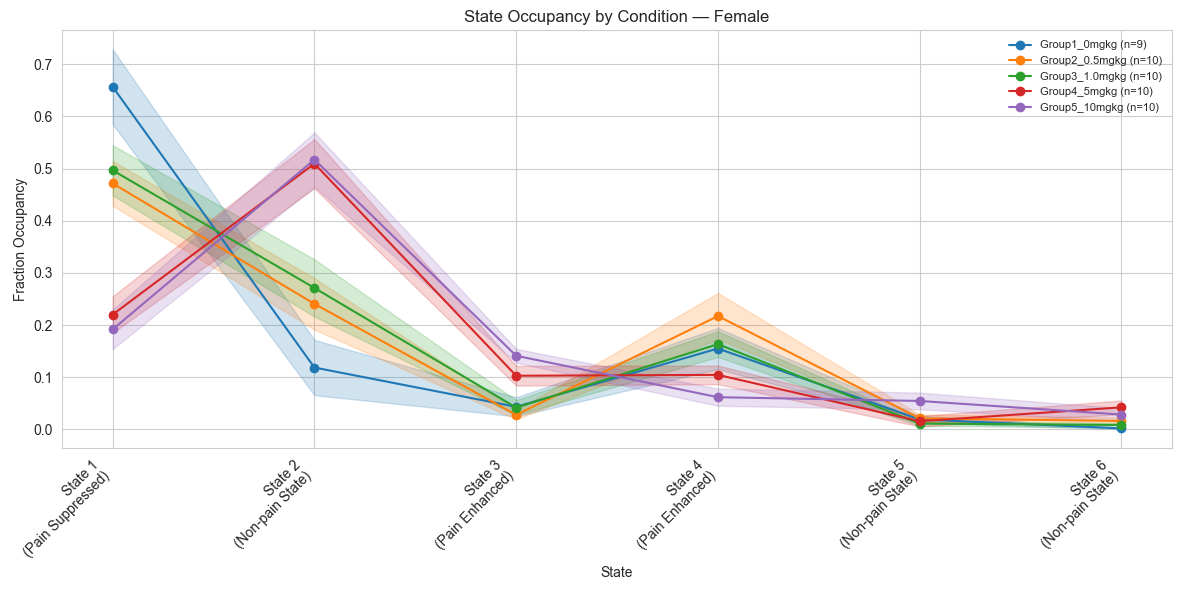

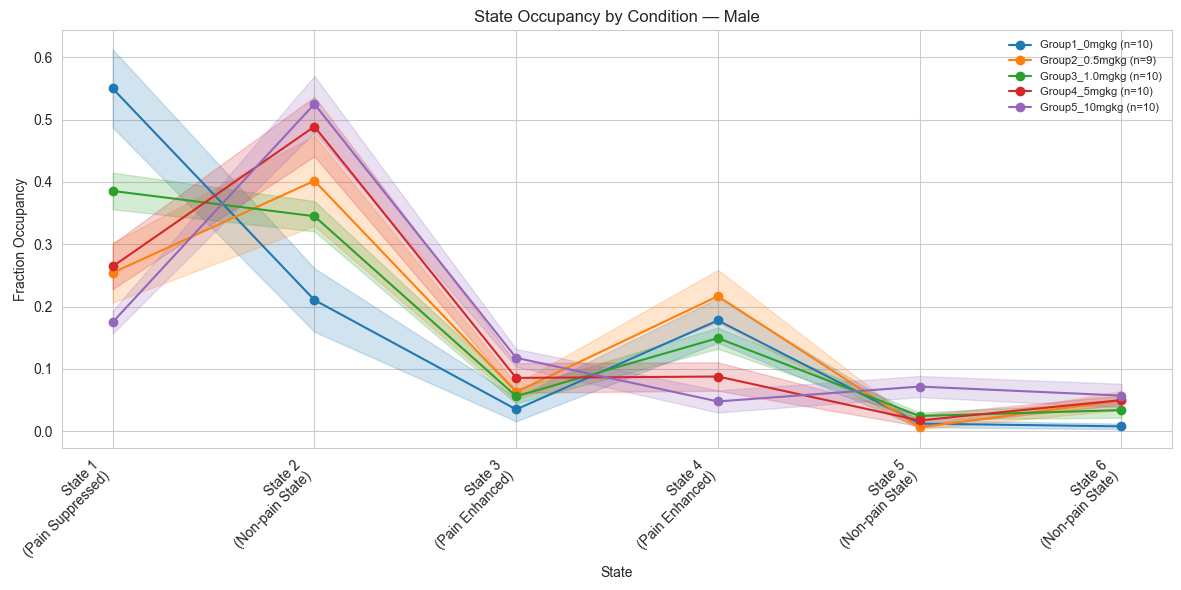

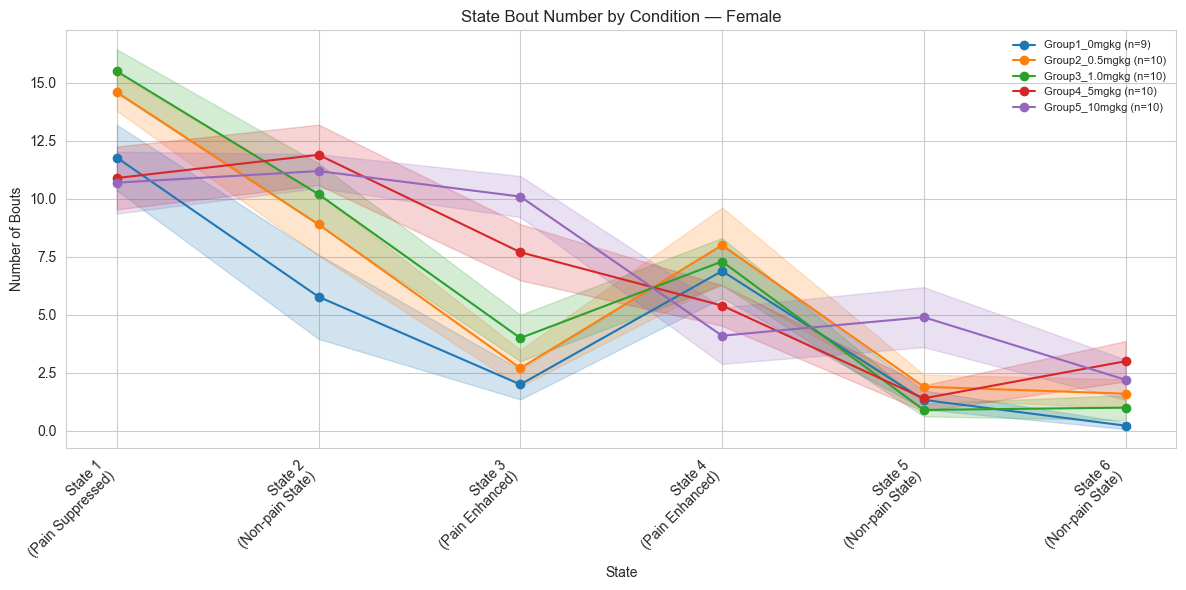

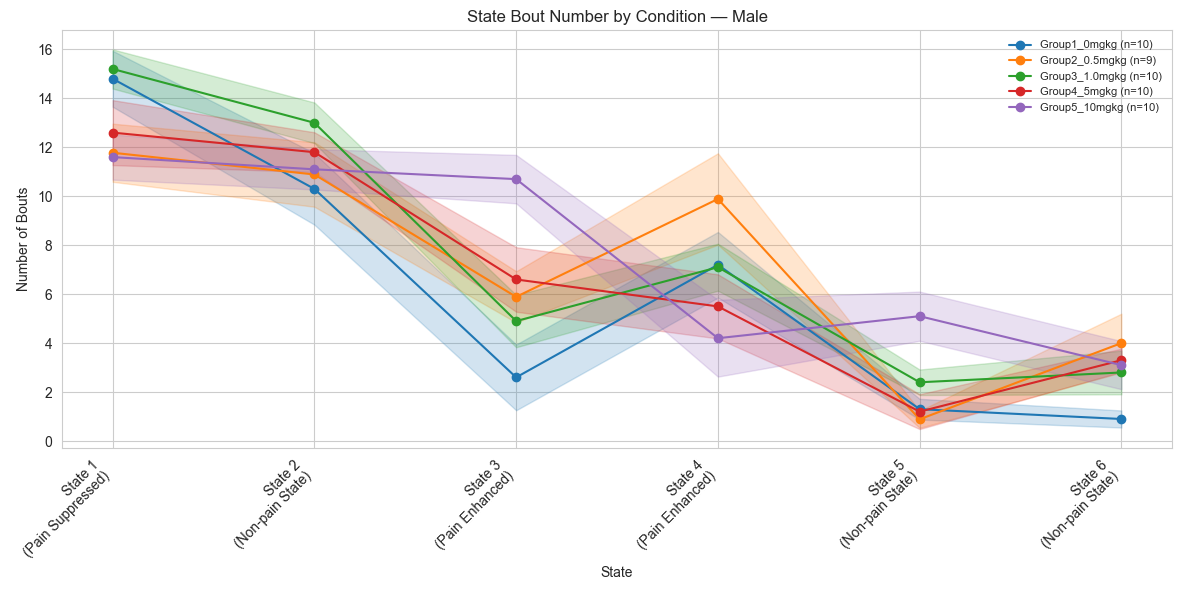

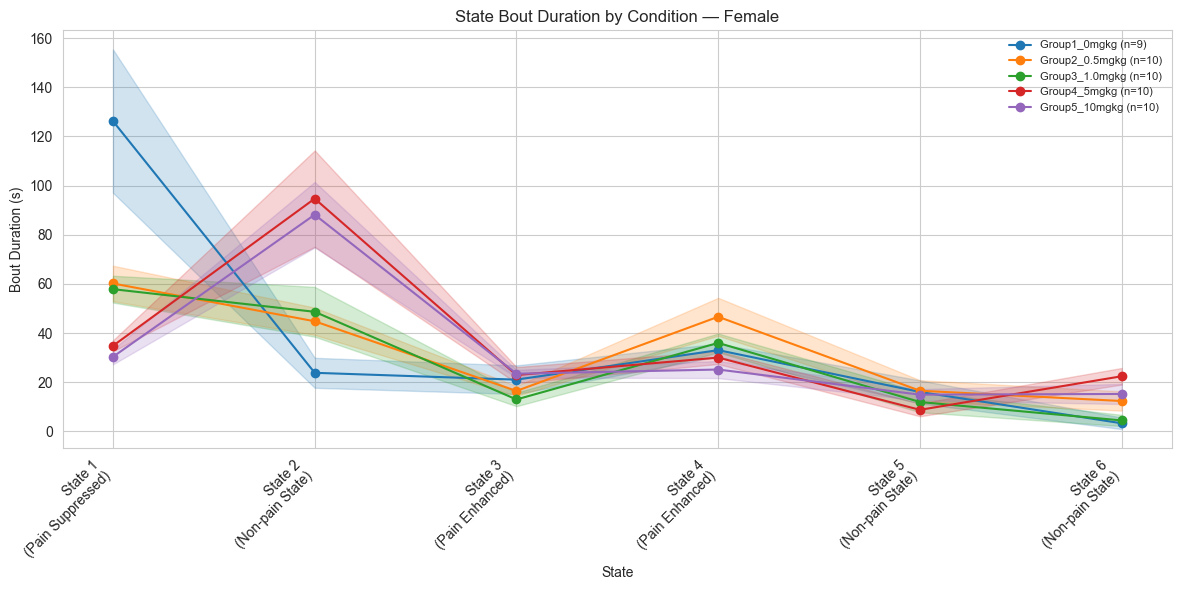

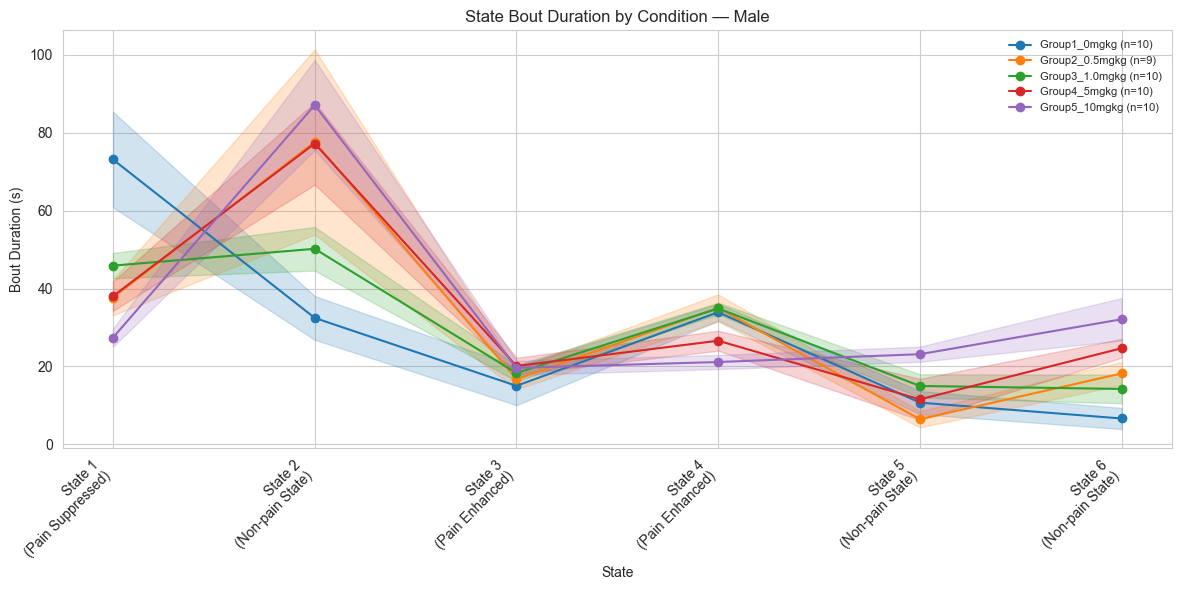

State visualizations saved to: ../processed_dataset/project_ACC_Study3_FormalinMorphine/figures/behaviors_LUPE-AMPS/Section8_StateViz
Summary CSVs exported (include Group, Condition, State):
  - project_ACC_Study3_FormalinMorphine_state_occupancy_summary.csv
  - project_ACC_Study3_FormalinMorphine_state_bouts_summary.csv
  - project_ACC_Study3_FormalinMorphine_state_duration_summary.csv
Per-group figures exported:
  - project_ACC_Study3_FormalinMorphine_state_occupancy_line_{Group}.png/svg
  - project_ACC_Study3_FormalinMorphine_state_bouts_line_{Group}.png/svg
  - project_ACC_Study3_FormalinMorphine_state_duration_line_{Group}.png/svg


In [31]:
output_dir_section8 = os.path.join(output_base_dir, 'Section8_StateViz')
os.makedirs(output_dir_section8, exist_ok=True)

# Display labels with category
states_display = [f"State {i+1}\n({state_categories[i+1]})" for i in range(6)]

# Generate plots per GROUP with lines by CONDITION

# --- 8a. State Occupancy by Condition (per group) ---
occupancy_summary = []

for group in unique_groups:
    fig, ax = plt.subplots(figsize=(12, 6))

    for cond in unique_conditions:
        mask = np.array([(g == group and c == cond) for g, c in zip(group_labels, condition_labels)])
        n_animals = int(np.sum(mask))

        if n_animals == 0:
            continue

        cond_data = total_fraction_state[mask, :]
        means = np.mean(cond_data, axis=0)
        sem = np.std(cond_data, axis=0, ddof=1) / np.sqrt(n_animals) if n_animals > 1 else np.zeros_like(means)

        x = np.arange(n_states)
        ax.plot(x, means, marker='o', label=f'{cond} (n={n_animals})', color=condition_colors[cond])
        ax.fill_between(x, means - sem, means + sem, alpha=0.2, color=condition_colors[cond])

        # Store for CSV (ONE State column only)
        for s in range(n_states):
            occupancy_summary.append({
                'Group': group,
                'Condition': cond,
                'State': state_column_names[s + 1],
                'Mean': means[s],
                'SEM': sem[s]
            })

    ax.set_xticks(range(n_states))
    ax.set_xticklabels(states_display, rotation=45, ha='right')
    ax.set_xlabel('State')
    ax.set_ylabel('Fraction Occupancy')
    ax.set_title(f'State Occupancy by Condition — {group}')
    ax.legend(fontsize=8, frameon=False)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir_section8, f'{project_name}_state_occupancy_line_{group}.png'), dpi=300)
    plt.savefig(os.path.join(output_dir_section8, f'{project_name}_state_occupancy_line_{group}.svg'))
    plt.show()

# Export occupancy summary CSV
pd.DataFrame(occupancy_summary).to_csv(
    os.path.join(output_dir_section8, f'{project_name}_state_occupancy_summary.csv'),
    index=False
)


# --- 8b. Number of Bouts by Condition (per group) ---
bouts_summary = []

for group in unique_groups:
    fig, ax = plt.subplots(figsize=(12, 6))

    for cond in unique_conditions:
        mask = np.array([(g == group and c == cond) for g, c in zip(group_labels, condition_labels)])
        n_animals = int(np.sum(mask))

        if n_animals == 0:
            continue

        cond_data = n_bouts_state[mask, :]
        means = np.mean(cond_data, axis=0)
        sem = np.std(cond_data, axis=0, ddof=1) / np.sqrt(n_animals) if n_animals > 1 else np.zeros_like(means)

        x = np.arange(n_states)
        ax.plot(x, means, marker='o', label=f'{cond} (n={n_animals})', color=condition_colors[cond])
        ax.fill_between(x, means - sem, means + sem, alpha=0.2, color=condition_colors[cond])

        # Store for CSV
        for s in range(n_states):
            bouts_summary.append({
                'Group': group,
                'Condition': cond,
                'State': state_column_names[s + 1],
                'Mean': means[s],
                'SEM': sem[s]
            })

    ax.set_xticks(range(n_states))
    ax.set_xticklabels(states_display, rotation=45, ha='right')
    ax.set_xlabel('State')
    ax.set_ylabel('Number of Bouts')
    ax.set_title(f'State Bout Number by Condition — {group}')
    ax.legend(fontsize=8, frameon=False)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir_section8, f'{project_name}_state_bouts_line_{group}.png'), dpi=300)
    plt.savefig(os.path.join(output_dir_section8, f'{project_name}_state_bouts_line_{group}.svg'))
    plt.show()

# Export bouts summary CSV
pd.DataFrame(bouts_summary).to_csv(
    os.path.join(output_dir_section8, f'{project_name}_state_bouts_summary.csv'),
    index=False
)


# --- 8c. Bout Duration by Condition (per group) ---
duration_summary = []

for group in unique_groups:
    fig, ax = plt.subplots(figsize=(12, 6))

    for cond in unique_conditions:
        mask = np.array([(g == group and c == cond) for g, c in zip(group_labels, condition_labels)])
        n_animals = int(np.sum(mask))

        if n_animals == 0:
            continue

        cond_data = bout_duration_state[mask, :]
        means = np.mean(cond_data, axis=0)
        sem = np.std(cond_data, axis=0, ddof=1) / np.sqrt(n_animals) if n_animals > 1 else np.zeros_like(means)

        x = np.arange(n_states)
        ax.plot(x, means, marker='o', label=f'{cond} (n={n_animals})', color=condition_colors[cond])
        ax.fill_between(x, means - sem, means + sem, alpha=0.2, color=condition_colors[cond])

        # Store for CSV
        for s in range(n_states):
            duration_summary.append({
                'Group': group,
                'Condition': cond,
                'State': state_column_names[s + 1],
                'Mean': means[s],
                'SEM': sem[s]
            })

    ax.set_xticks(range(n_states))
    ax.set_xticklabels(states_display, rotation=45, ha='right')
    ax.set_xlabel('State')
    ax.set_ylabel('Bout Duration (s)')
    ax.set_title(f'State Bout Duration by Condition — {group}')
    ax.legend(fontsize=8, frameon=False)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir_section8, f'{project_name}_state_duration_line_{group}.png'), dpi=300)
    plt.savefig(os.path.join(output_dir_section8, f'{project_name}_state_duration_line_{group}.svg'))
    plt.show()

# Export duration summary CSV
pd.DataFrame(duration_summary).to_csv(
    os.path.join(output_dir_section8, f'{project_name}_state_duration_summary.csv'),
    index=False
)

print(f"State visualizations saved to: {output_dir_section8}")
print(f"Summary CSVs exported (include Group, Condition, State):")
print(f"  - {project_name}_state_occupancy_summary.csv")
print(f"  - {project_name}_state_bouts_summary.csv")
print(f"  - {project_name}_state_duration_summary.csv")
print(f"Per-group figures exported:")
print(f"  - {project_name}_state_occupancy_line_{{Group}}.png/svg")
print(f"  - {project_name}_state_bouts_line_{{Group}}.png/svg")
print(f"  - {project_name}_state_duration_line_{{Group}}.png/svg")

### Section 9: PCA PROJECTION - AMPS CALCULATION

Loading PCA parameters from: ../model/pain_scale_params.mat
PCA coeff shape: (6, 6)
PCA mean shape: (6,)

AMPS Scores Calculated:
  General Behavior Scale (PC1) range: [-0.709, 0.353]
  AMPS (PC2) range: [-0.383, 0.360]


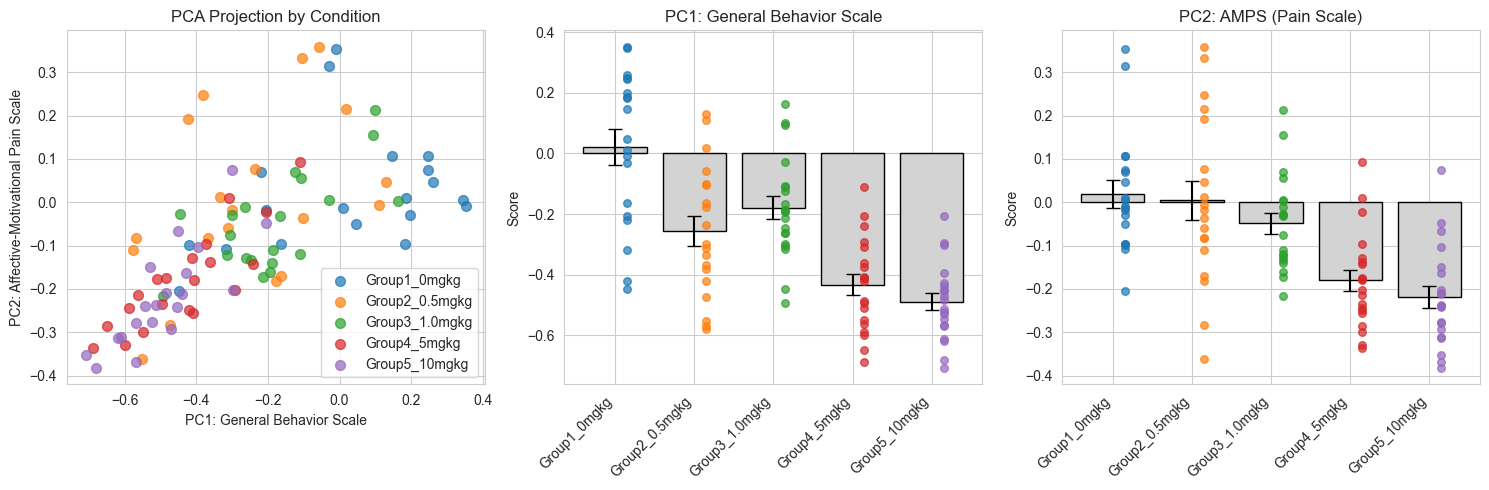


AMPS results saved to: ../processed_dataset/project_ACC_Study3_FormalinMorphine/figures/behaviors_LUPE-AMPS/Section9_AMPS


In [22]:
def load_pca_params(pca_path):
    """Load PCA parameters from file."""
    if pca_path.endswith('.pkl'):
        with open(pca_path, 'rb') as f:
            data = pickle.load(f)
            if hasattr(data, 'components_'):
                # sklearn PCA object
                return data.components_.T, data.mean_
            elif isinstance(data, dict):
                coeff = np.array(data.get('coeff', data.get('components_', None)))
                mu = np.array(data.get('mu', data.get('mean_', np.zeros(6))))
                return coeff, mu
            else:
                raise ValueError("Unrecognized PCA format")
    elif pca_path.endswith('.mat'):
        from scipy.io import loadmat
        data = loadmat(pca_path)
        
        # Handle MATLAB struct format (pain_scale_params.coeff, pain_scale_params.mu)
        if 'pain_scale_params' in data:
            # MATLAB struct - access nested fields
            params = data['pain_scale_params']
            coeff = np.array(params['coeff'][0, 0])
            mu = np.array(params['mu'][0, 0]).squeeze()
            return coeff, mu
        # Handle direct variable format (coeff, mu as separate variables)
        elif 'coeff' in data and 'mu' in data:
            coeff = np.array(data['coeff']).squeeze()
            mu = np.array(data['mu']).squeeze()
            return coeff, mu
        else:
            raise KeyError(f"Could not find PCA params in .mat file. Keys: {[k for k in data.keys() if not k.startswith('__')]}")
    else:
        raise ValueError(f"Unsupported file format: {pca_path}")


def project_to_pc_space(state_occupancy, coeff, mu):
    """Project state occupancy data into PC space."""
    centered = state_occupancy - mu
    projected = centered @ coeff[:, :2]
    return projected


# Load PCA parameters
print(f"Loading PCA parameters from: {pca_model_path}")
try:
    pca_coeff, pca_mu = load_pca_params(pca_model_path)
    print(f"PCA coeff shape: {pca_coeff.shape}")
    print(f"PCA mean shape: {pca_mu.shape}")
except Exception as e:
    print(f"Error loading PCA params: {e}")
    print("Fitting PCA on current data...")
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2)
    pca.fit(total_fraction_state)
    pca_coeff = pca.components_.T
    pca_mu = pca.mean_

# Project to PC space
pca_projection = project_to_pc_space(total_fraction_state, pca_coeff, pca_mu)
general_behavior_scale = pca_projection[:, 0]  # PC1
amps = pca_projection[:, 1]  # PC2 - Affective-Motivational Pain Scale

print(f"\nAMPS Scores Calculated:")
print(f"  General Behavior Scale (PC1) range: [{general_behavior_scale.min():.3f}, {general_behavior_scale.max():.3f}]")
print(f"  AMPS (PC2) range: [{amps.min():.3f}, {amps.max():.3f}]")

# Export AMPS scores
output_dir_section9 = os.path.join(output_base_dir, 'Section9_AMPS')
os.makedirs(output_dir_section9, exist_ok=True)

df_amps = pd.DataFrame({
    'Animal': animal_names,
    'Group': group_labels,
    'Condition': condition_labels,
    'PC1_GeneralBehaviorScale': general_behavior_scale,
    'PC2_AMPS': amps
})
df_amps.to_csv(os.path.join(output_dir_section9, f'{project_name}_amps_scores.csv'), index=False)

# PCA Scatter Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Scatter by condition
ax = axes[0]
for cond in unique_conditions:
    mask = np.array([c == cond for c in condition_labels])
    ax.scatter(
        general_behavior_scale[mask], 
        amps[mask],
        c=[condition_colors[cond]],
        label=cond,
        s=50,
        alpha=0.7
    )
ax.set_xlabel('PC1: General Behavior Scale')
ax.set_ylabel('PC2: Affective-Motivational Pain Scale')
ax.set_title('PCA Projection by Condition')
ax.legend()

# Bar plot for PC1
ax = axes[1]
means = []
sems = []
for cond in unique_conditions:
    mask = np.array([c == cond for c in condition_labels])
    data = general_behavior_scale[mask]
    means.append(np.mean(data))
    sems.append(np.std(data, ddof=1) / np.sqrt(len(data)))

x = np.arange(len(unique_conditions))
ax.bar(x, means, yerr=sems, capsize=5, color='lightgray', edgecolor='black')
for i, cond in enumerate(unique_conditions):
    mask = np.array([c == cond for c in condition_labels])
    data = general_behavior_scale[mask]
    ax.scatter(np.ones(len(data)) * i + 0.15, data, c=[condition_colors[cond]], s=30, alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(unique_conditions, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('PC1: General Behavior Scale')

# Bar plot for AMPS
ax = axes[2]
means = []
sems = []
for cond in unique_conditions:
    mask = np.array([c == cond for c in condition_labels])
    data = amps[mask]
    means.append(np.mean(data))
    sems.append(np.std(data, ddof=1) / np.sqrt(len(data)))

x = np.arange(len(unique_conditions))
ax.bar(x, means, yerr=sems, capsize=5, color='lightgray', edgecolor='black')
for i, cond in enumerate(unique_conditions):
    mask = np.array([c == cond for c in condition_labels])
    data = amps[mask]
    ax.scatter(np.ones(len(data)) * i + 0.15, data, c=[condition_colors[cond]], s=30, alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(unique_conditions, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('PC2: AMPS (Pain Scale)')

plt.tight_layout()
plt.savefig(os.path.join(output_dir_section9, f'{project_name}_amps_projection.png'), dpi=300)
plt.savefig(os.path.join(output_dir_section9, f'{project_name}_amps_projection.svg'))
plt.show()

print(f"\nAMPS results saved to: {output_dir_section9}")

### Section 10: SUMMARY

In [26]:
# Print Summary
print("LUPE-AMPS ANALYSIS COMPLETE")
print(f"\nProject: {project_name}")
print(f"Animals analyzed: {len(animal_names)}")
print(f"Groups: {selected_groups}")
print(f"Conditions: {selected_conditions}")
print(f"\nOutput directory: {output_base_dir}")
print("\nKey outputs:")
print(f"  - AMPS scores: {output_dir_section9}/{project_name}_amps_scores.csv")
print(f"  - State statistics: {output_dir_section7}/")
print(f"  - Behavior statistics: {output_dir_section2}/")

LUPE-AMPS ANALYSIS COMPLETE

Project: project_ACC_Study3_FormalinMorphine
Animals analyzed: 98
Groups: ['Male', 'Female']
Conditions: ['Group1_0mgkg', 'Group2_0.5mgkg', 'Group3_1.0mgkg', 'Group4_5mgkg', 'Group5_10mgkg']

Output directory: ../processed_dataset/project_ACC_Study3_FormalinMorphine/figures/behaviors_LUPE-AMPS

Key outputs:
  - AMPS scores: ../processed_dataset/project_ACC_Study3_FormalinMorphine/figures/behaviors_LUPE-AMPS/Section9_AMPS/project_ACC_Study3_FormalinMorphine_amps_scores.csv
  - State statistics: ../processed_dataset/project_ACC_Study3_FormalinMorphine/figures/behaviors_LUPE-AMPS/Section7_StateStats/
  - Behavior statistics: ../processed_dataset/project_ACC_Study3_FormalinMorphine/figures/behaviors_LUPE-AMPS/Section2_BehaviorStats/


## Complete